# Librairies

In [118]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

from sklearn.impute import MissingIndicator, KNNImputer, SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.util import Surv
from sklearn.model_selection import KFold, GridSearchCV
from statsmodels.stats.multitest import multipletests
from sksurv.metrics import concordance_index_censored

# Data 

In [119]:
# Data
df_clinical = pd.read_csv("X_train/clinical_train.csv")
df_molecular = pd.read_csv("X_train/molecular_train.csv")
df_y = pd.read_csv("target_train.csv")

# Size
print(
    "df_clinical:",
    df_clinical.shape,
    " | df_y:",
    df_y.shape,
    " | df_molecular:",
    df_molecular.shape,
)


print("ID unique in clincal dataset and molecular dataset")
print("Clinical unique IDs:", df_clinical["ID"].nunique())
print("Molecular unique IDs:", df_molecular["ID"].nunique())

df_clinical: (3323, 9)  | df_y: (3323, 3)  | df_molecular: (10935, 11)
ID unique in clincal dataset and molecular dataset
Clinical unique IDs: 3323
Molecular unique IDs: 3026


In [120]:
print("Patients avant nettoyage:", df_y.shape[0])
print("Patients sans labels:", df_y[["OS_YEARS", "OS_STATUS"]].isna().any(axis=1).sum())

Patients avant nettoyage: 3323
Patients sans labels: 150


Certains patients du fichier target_train.csv ont des étiquettes de survie manquantes (OS_YEARS et OS_STATUS non renseignés). Ces patients ont été exclus de l’entraînement car l’analyse de survie nécessite un temps observé et un indicateur d’événement.”

# Exploratoire Data Analysis (EDA)

## 1/ EDA for Clinical Data 

GLobal information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3323 entries, 0 to 3322
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            3323 non-null   object 
 1   CENTER        3323 non-null   object 
 2   BM_BLAST      3214 non-null   float64
 3   WBC           3051 non-null   float64
 4   ANC           3130 non-null   float64
 5   MONOCYTES     2722 non-null   float64
 6   HB            3213 non-null   float64
 7   PLT           3199 non-null   float64
 8   CYTOGENETICS  2936 non-null   object 
dtypes: float64(6), object(3)
memory usage: 233.8+ KB


None

Missing values


ID                0
CENTER            0
BM_BLAST        109
WBC             272
ANC             193
MONOCYTES       601
HB              110
PLT             124
CYTOGENETICS    387
OS_YEARS        150
OS_STATUS       150
dtype: int64

We have 867 missing values in the clinical dataset


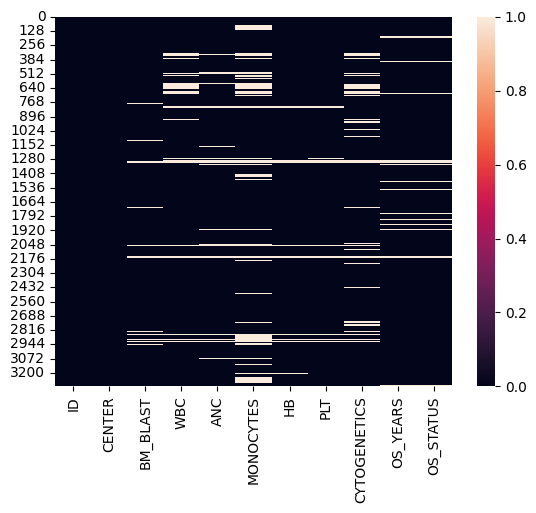

In [121]:
# Global information
print("GLobal information:")
display(df_clinical.info())

# Join data
df = df_clinical.merge(df_y, on="ID")

# Miising values clinical +target
print("Missing values")
display(df.isna().sum(axis=0))
# heatmap for df_clinical + target
sns.heatmap(df.isna())
na_clinical_index = df[df.isna().any(axis=1)].index
print(f"We have {len(na_clinical_index)} missing values in the clinical dataset")

In [122]:
df_eda = df.copy()

# Variables catégorielles
categorical_vars = ["CENTER", "CYTOGENETICS", "OS_STATUS"]

# Variables continues
continuous_vars = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]

# Variables target
target_vars = ["OS_YEARS"]

print("Variables catégorielles :", categorical_vars)
print("Variables continues :", continuous_vars)
print("Variables target :", target_vars)

Variables catégorielles : ['CENTER', 'CYTOGENETICS', 'OS_STATUS']
Variables continues : ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
Variables target : ['OS_YEARS']


#### 1/ Univariate Analysis

#### -> Discrete variable


=== CENTER ===
CENTER
KI       900
DUS      455
PV       316
GESMD    246
RMCN     199
CCH      159
CGM      107
ROM      104
UOB       88
MUV       83
HMS       83
TUD       73
FUCE      73
ICO       71
FLO       68
DUTH      66
UOXF      50
HIAE      47
MSK       37
IHBT      33
VU        33
UMG       26
REL        6
Name: count, dtype: int64


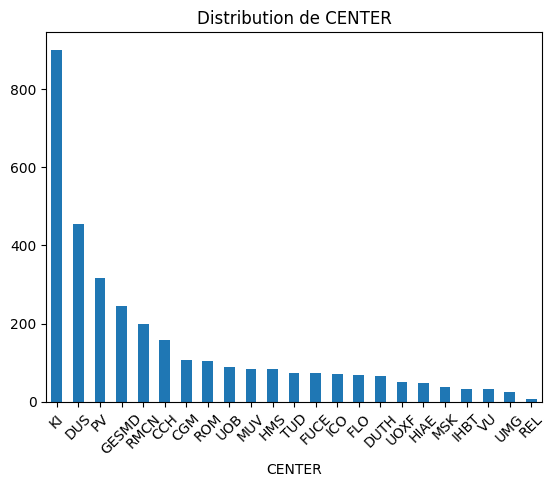


=== CYTOGENETICS ===
CYTOGENETICS
46,xy[20]                                                                        432
NaN                                                                              387
46,xy                                                                            276
46,xx[20]                                                                        254
46,xx                                                                            192
                                                                                ... 
45,x,-y[16]/46,xy[14]                                                              1
44-45,xy,-5,der(6)del(6)(?q13q15)t(6;15)(p25;p13),-15,-18,+mar[cp10]/46,xy[4]      1
46,xx,del(5)(q13q33)[12]/46,xx[8]                                                  1
47,xx,+15[3]/46,xx[17]                                                             1
45,xy,-7[16]/46,xy[1]                                                              1
Name: count, Length: 1195, dty

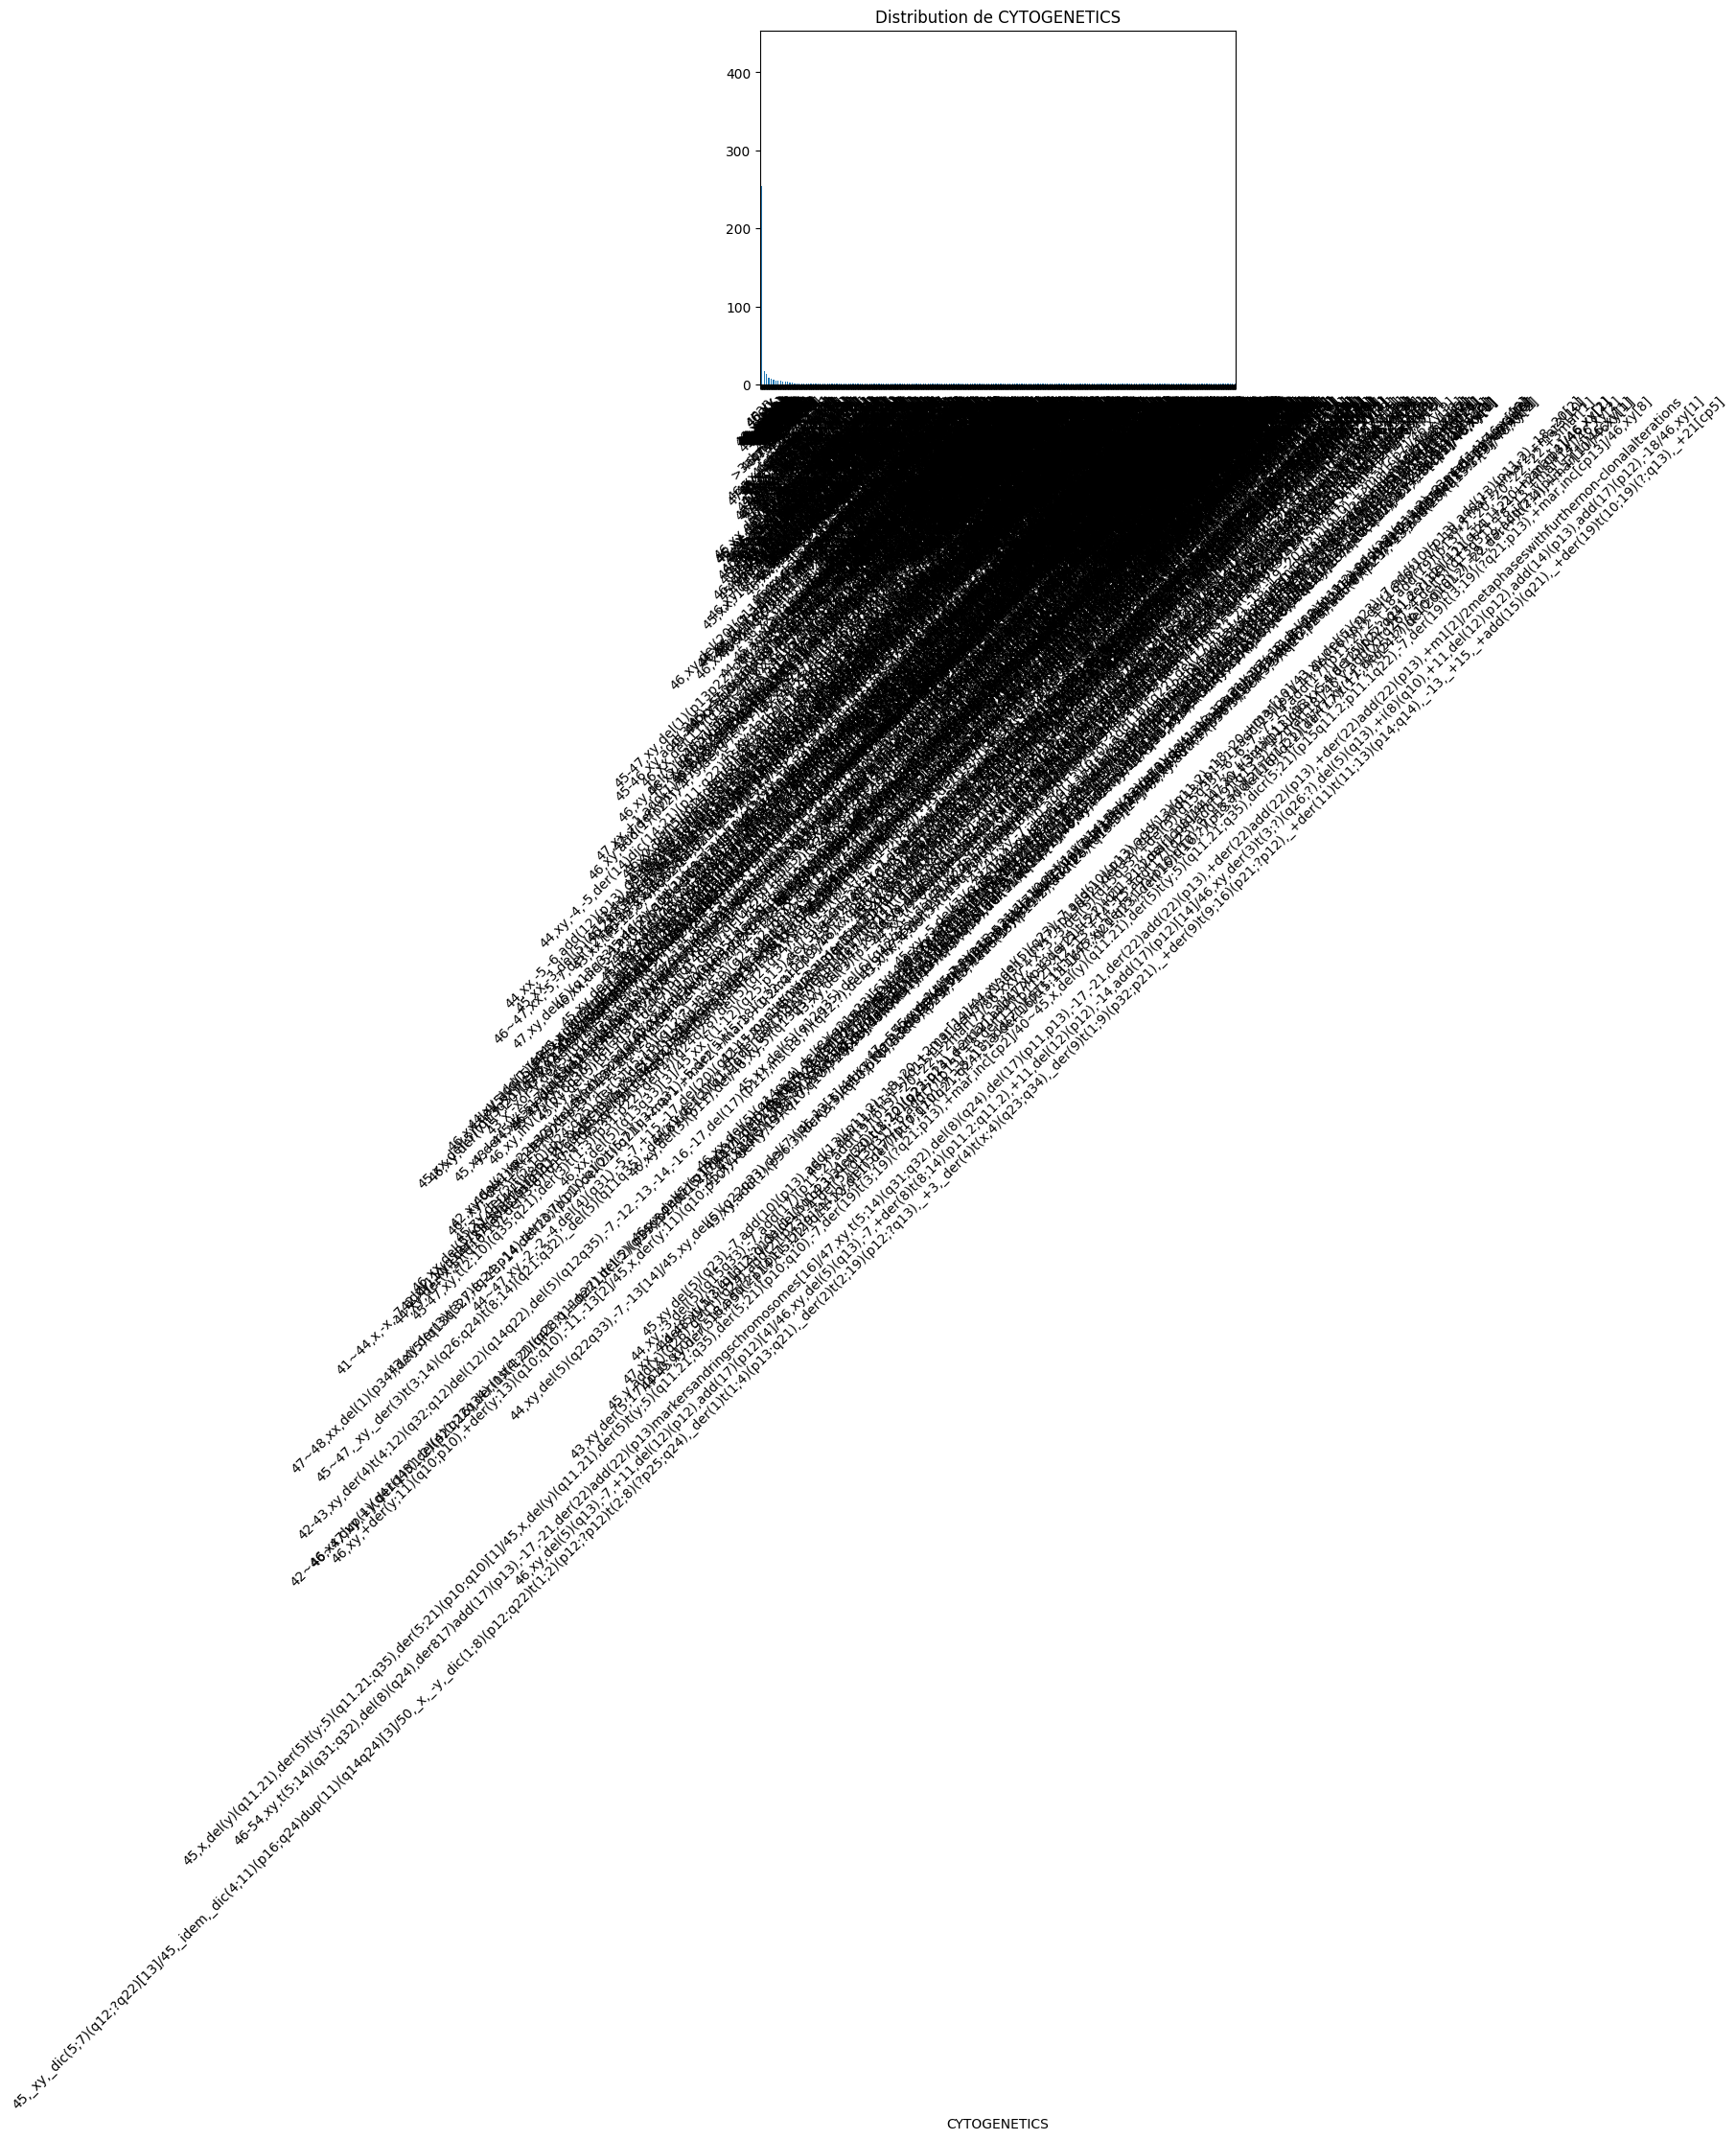


=== OS_STATUS ===
OS_STATUS
1.0    1600
0.0    1573
NaN     150
Name: count, dtype: int64


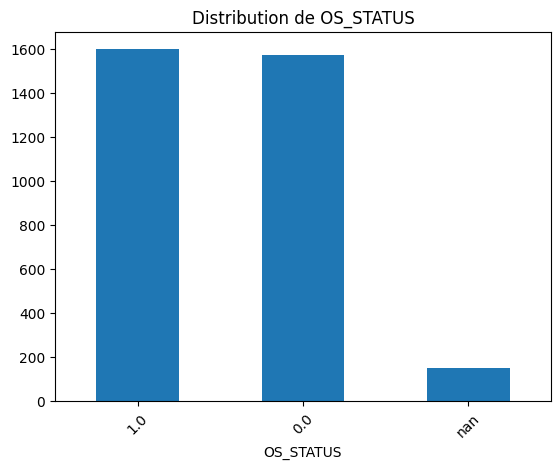

In [123]:
for col in categorical_vars:
    print(f"\n=== {col} ===")
    print(df_eda[col].value_counts(dropna=False))

    df_eda[col].value_counts(dropna=False).plot(kind="bar", rot=45)
    plt.title(f"Distribution de {col}")
    plt.show()

- In this dataset , a large majority of patients have been traited in hospital center like: **KI, PV , DUS, and GESMD**. Note the large hospital center in terms of number of patients traited is **KI** which has **695 patients**

- We have **1253 patients** who were alive during the last screening and **1203 patients** who were declared passed away in this dataset. 

#### Analyse of the **CYTOGENETICS** variable

In [124]:
df["CYTOGENETICS"]

0                         46,xy,del(20)(q12)[2]/46,xy[18]
1                                                   46,xx
2                      46,xy,t(3;3)(q25;q27)[8]/46,xy[12]
3                       46,xy,del(3)(q26q27)[15]/46,xy[5]
4                     46,xx,t(3;9)(p13;q22)[10]/46,xx[10]
                              ...                        
3318                                            46,xy[20]
3319    46,xy,del(13)(q12q14)[1]/45,x,-y,del(13)(q12q1...
3320       46,xy,del(20)(q11.2q13.1)[4]/45,xy,idem,-7[16]
3321    46,xx,del(1)(p34)[5]/45,xx,sl,-18[12]/46,xx,sd...
3322                                            46,xy[20]
Name: CYTOGENETICS, Length: 3323, dtype: object

In [125]:
print("Number of unique values:", df_eda["CYTOGENETICS"].nunique())
print("Number of missing values :", df_eda["CYTOGENETICS"].isna().sum())
df_eda["CYTOGENETICS"].value_counts().head(10)

Number of unique values: 1194
Number of missing values : 387


CYTOGENETICS
46,xy[20]    432
46,xy        276
46,xx[20]    254
46,xx        192
46,xy[25]     61
46,xx[25]     38
46,xy[21]     33
46,xx[26]     23
46,xy[26]     21
46,xy[23]     18
Name: count, dtype: int64

This variable contains caryotypes coded in ISCN format. These codes describe the chromosomal abnormalities of a patient with leukemia.

Note that within this variable, there are 1194 different groups. It is therefore essential to group them into major families according to biological standards. The **cytogentic_group** function analyzes each group and classifies each karyotype into a family.

In [126]:
def cytogenetic_group(x):
    if pd.isna(x):
        return np.nan
    x = x.lower()

    # Normal karyotype
    if (
        "46,xx" in x
        and "del" not in x
        and "t(" not in x
        and "-7" not in x
        and "+8" not in x
    ):
        return "Normal"
    if (
        "46,xy" in x
        and "del" not in x
        and "t(" not in x
        and "-7" not in x
        and "+8" not in x
    ):
        return "Normal"

    # AML recurrent anomalies
    if "-7" in x:
        return "Monosomy 7"
    if "del(5" in x or "5q" in x:
        return "5q deletion"
    if "+8" in x:
        return "Trisomy 8"
    if "t(8;21)" in x:
        return "t(8;21)"
    if "inv(16" in x:
        return "inv(16)"
    if "t(15;17)" in x:
        return "APL t(15;17)"

    # Complex karyotype = >= 3 anomalies
    # Subdivision into several clones
    primary_clone = x.split("/")[0]
    if primary_clone.count(",") >= 3:
        return "Complex"

    return "Other"

In [127]:
df_eda["CYTO_CLASS"] = df_eda["CYTOGENETICS"].apply(cytogenetic_group)
df_eda["CYTO_CLASS"].value_counts()

CYTO_CLASS
Normal          1903
5q deletion      301
Other            299
Trisomy 8        183
Monosomy 7       169
Complex           80
APL t(15;17)       1
Name: count, dtype: int64

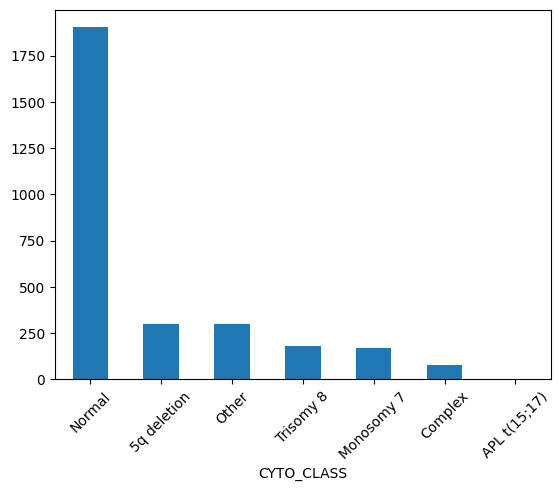

In [128]:
df_eda["CYTO_CLASS"].value_counts().plot(kind="bar", rot=45)
plt.show()

#### -> Continuous variables 

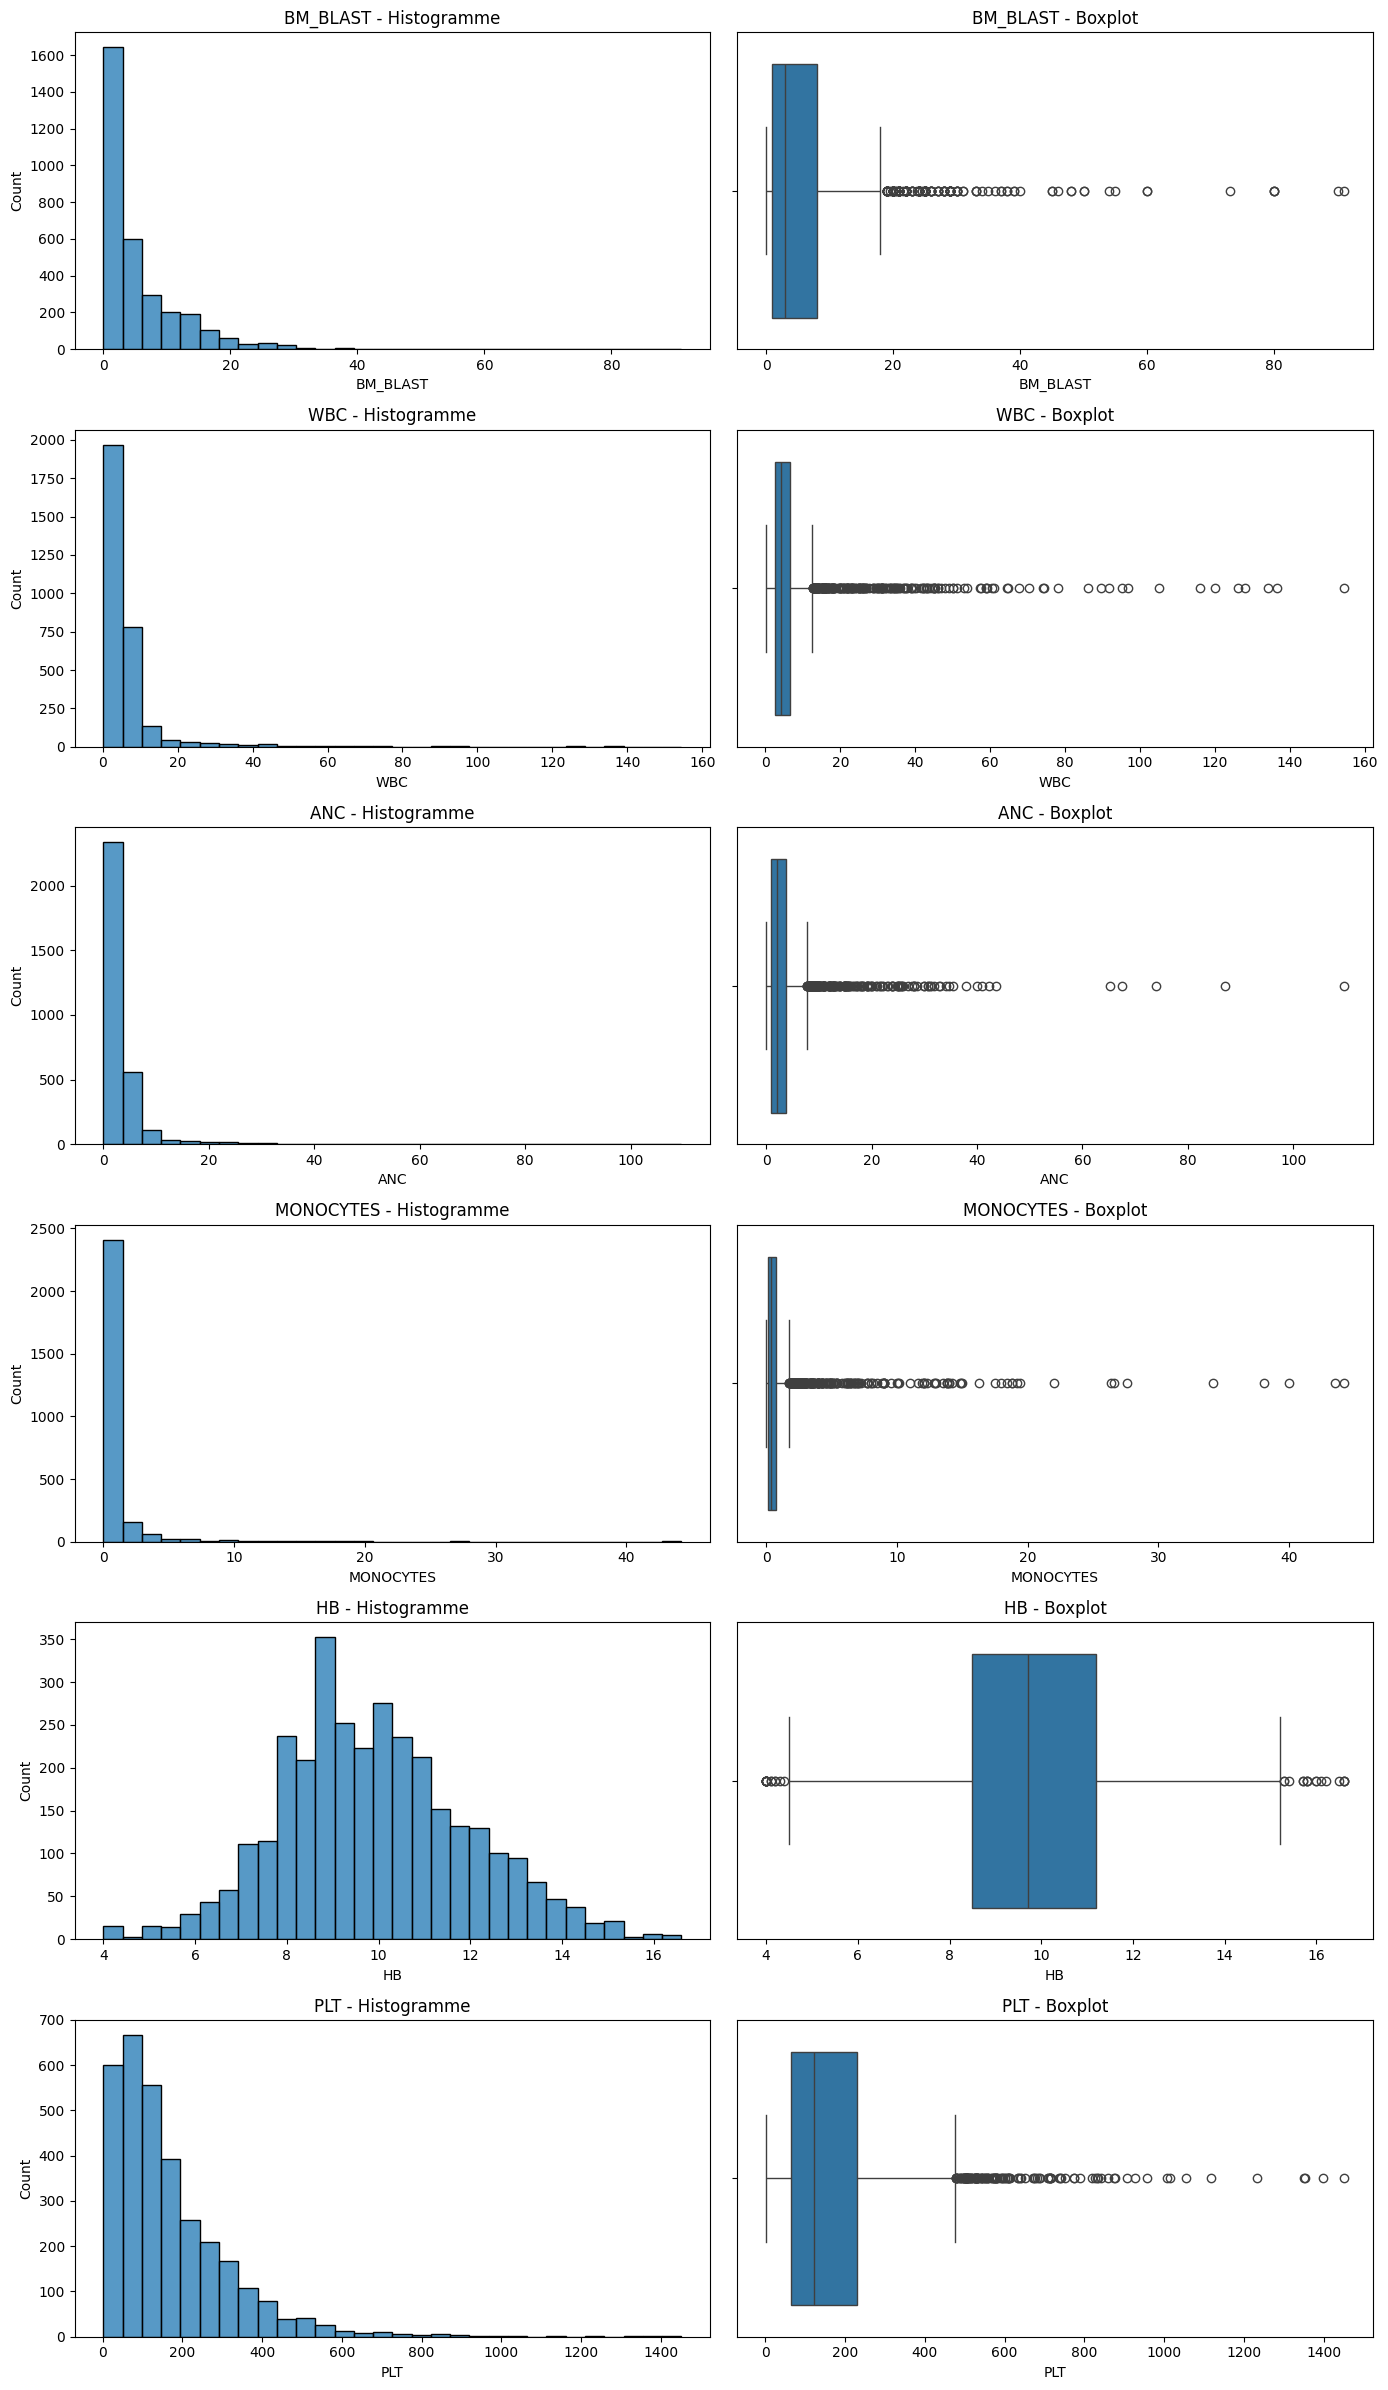

In [129]:
continuous_vars = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]

n = len(continuous_vars)
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(14, 4 * n))

for i, col in enumerate(continuous_vars):
    sns.histplot(df_eda[col].dropna(), bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} - Histogramme")

    sns.boxplot(x=df_eda[col].dropna(), ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} - Boxplot")

plt.tight_layout()
plt.show()

In [130]:
continuous_vars = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]

for col in continuous_vars:
    s = df_eda[col].dropna()
    mean = s.mean()
    std = s.std()
    vmin = s.min()
    vmax = s.max()

    zero_count = df_eda.query(f"{col} == 0").shape[0]
    min_count = df_eda.query(f"{col} == @vmin").shape[0]
    max_count = df_eda.query(f"{col} == @vmax").shape[0]

    print(
        f"{col} | mean={mean:.2f} | std={std:.2f} | min={vmin} (n={min_count}) | "
        f"max={vmax} (n={max_count}) | zeros={zero_count}"
    )

BM_BLAST | mean=5.98 | std=7.62 | min=0.0 (n=310) | max=91.0 (n=1) | zeros=310
WBC | mean=6.54 | std=10.25 | min=0.2 (n=1) | max=154.4 (n=1) | zeros=0
ANC | mean=3.26 | std=5.24 | min=0.0 (n=23) | max=109.62 (n=1) | zeros=23
MONOCYTES | mean=0.96 | std=2.67 | min=0.0 (n=219) | max=44.2 (n=1) | zeros=219
HB | mean=9.89 | std=2.04 | min=4.0 (n=10) | max=16.6 (n=3) | zeros=0
PLT | mean=167.05 | std=149.48 | min=2.0 (n=2) | max=1451.0 (n=1) | zeros=0


#### Univariate Summary of Hematological Variables

- **Bone marrow blasts (BM_BLAST):**  
  On average, patients present **5.98%** bone marrow blasts, with a standard deviation of **7.62**.  
  A total of **310 patients** show no blasts in the marrow.  
  The maximum observed value reaches **91%**, found in **1 patient**.

- **White blood cells (WBC):**  
  The mean WBC count is **6.54 G/L**, with a standard deviation of **10.25**.  
  The minimum leukocyte count is **0.20 G/L** (1 patient), while the maximum reaches **154.40 G/L** (1 patient).

- **Neutrophils (ANC):**  
  The mean ANC is **3.26 G/L**, with a standard deviation of **5.24**.  
  A total of **23 patients** have a null ANC.  
  Observed values range from **0.0 G/L** to **109.62 G/L**.

- **Monocytes:**  
  The mean monocyte count is **0.96 G/L**, with a standard deviation of **2.67**.  
  **219 patients** have a monocyte count equal to 0.  
  The maximum measured value is **44.20 G/L**.

- **Hemoglobin (HB):**  
  The mean hemoglobin level is **9.89 g/dL**, with a standard deviation of **2.04**.  
  Values range from **4.0 g/dL** (observed in 10 patients) to **16.6 g/dL** (observed in 3 patients).

- **Platelets (PLT):**  
  The mean platelet count is **167.05 G/L**, with a standard deviation of **149.48**.  
  Observed values range from **2.0 G/L** (2 patients) to **1451.0 G/L** (1 patient).


### 2/ Multivariate Analysis

2.1/ Correlation between continuous variables

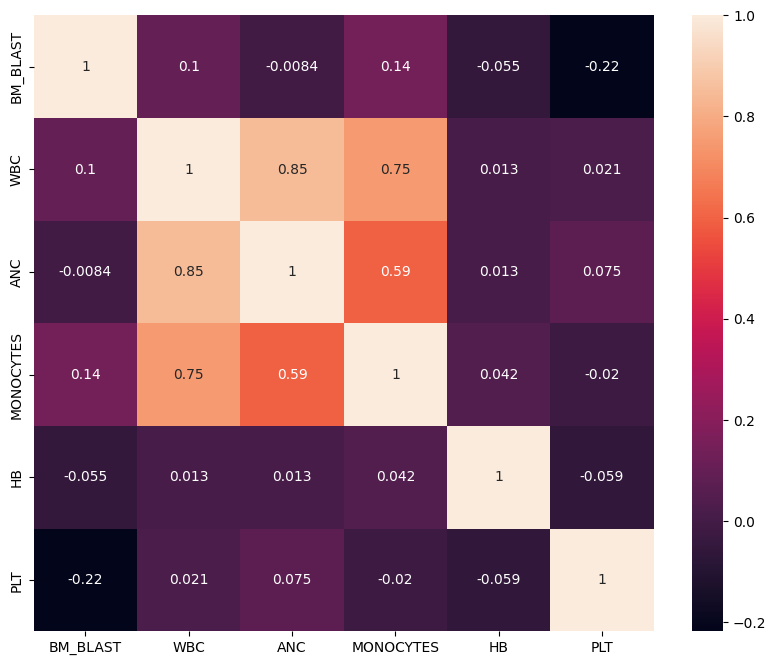

In [131]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_eda[continuous_vars].corr(), annot=True)
plt.show()

Analysis of the correlation matrix reveals that the hematological variables WBC, ANC, and MONOCYTES are strongly correlated with each other, reflecting redundancy of information.

Conversely, the variables BM_BLAST, HB, and PLT show little or no correlation with the other parameters. They therefore appear to provide unique and complementary information, which could be relevant for constructing the survival model.

2.2/ Distibution of survival according to centers (CENTER)

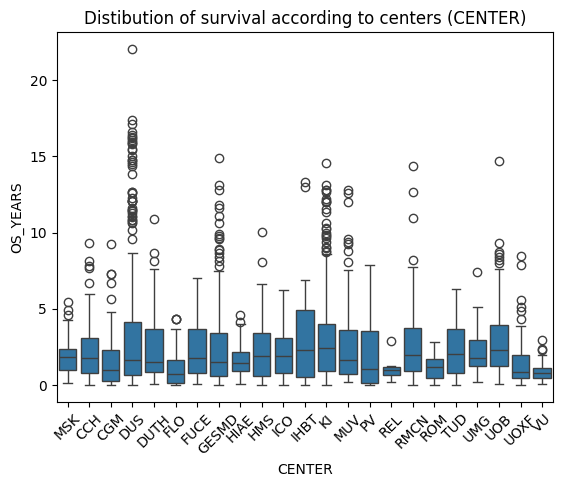

In [132]:
sns.boxplot(data=df_eda, x="CENTER", y="OS_YEARS")
plt.title("Distibution of survival according to centers (CENTER)")
plt.xticks(rotation=45)
plt.show()

<div style="background-color:#e8d9ec; color:black; padding:10px; border-radius:5px; border:2px solid #b58db6;">
The distribution of survival rates across centers shows that median survival rates appear relatively similar, with values ​​generally ranging from 1 to 2 years. It therefore appears that survival distributions are similar between centers.

However, some centers exhibit particularly high survival rates, corresponding to a few patients who survived for extended periods, thus increasing the overall dispersion among these centers.
These observations remain descriptive. They do not allow us to conclude whether or not there are significant differences in survival rates between centers. Appropriate statistical tests will be necessary to assess whether the center is indeed a factor influencing overall survival. <span style="color:red; font-weight:bold;">(Test 1)</span>
</div>


2.3/ Relationship between survival and continuous variables

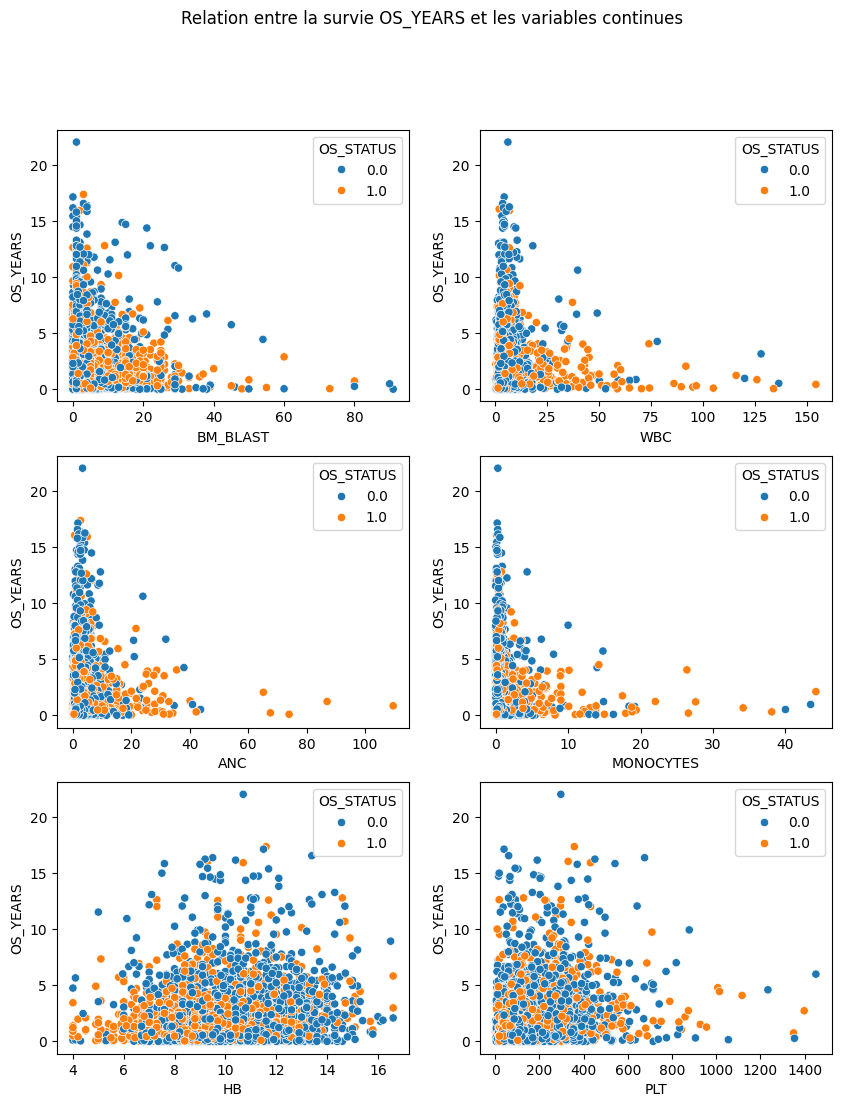

In [133]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.ravel()
for i, col_name in enumerate(continuous_vars):
    sns.scatterplot(data=df_eda, x=col_name, y="OS_YEARS", hue="OS_STATUS", ax=axes[i])
plt.suptitle("Relation entre la survie OS_YEARS et les variables continues")
plt.show()

<div style="background-color:#e8d9ec; color:black; padding:10px; border-radius:5px; border:1px solid #b58db6;">
L'analyse des graphes ci-dessusn, nous montre que ,  pour plusieurs variables biologiques tels que: **BM_BLAST, WBC,ANC, MONOCYTES, PLT**, les valeurs les plus élevées semblent être associées à des survies plus courtes. Cela  mais suggère donc une corrélation négative  avec la varibale **OS_YEARS** .Par ailleurs, la majorité des patients présentent une survie inférieure à 5 ans, ce qui concentre une grande partie des points dans cette zone et rend les tendances moins visibles.

Certaines variables présentent des valeurs extrêmes très élevées notamment WBC, ANC, MONOCYTES, PLT, ce qui étire l’axe horizontal et peut refléter des situations cliniques particulières. À l’inverse, HB ne montre pas de tendance apparente avec la survie, les points sont dispersés de manière relativement homogènes.
Ces observations restent exploratoires : elles servent surtout à identifier les variables qui pourraient jouer un rôle dans la survie avant d’appliquer une analyse statistique formelle.



Au vu de ces observations exploratoires, plusieurs hypothèses statistiques peuvent être formulées afin de vérifier si les tendances visuelles reflètent effectivement une association avec la survie :

- H1 – BM_BLAST influence la survie :
    Les patients présentant un taux élevé de blasts médullaires pourraient avoir une survie plus courte.

- H2 – WBC influence la survie :
    Des valeurs élevées de leucocytes pourraient être associées à une augmentation du risque de décès.

- H3 – ANC influence la survie :
    Un taux élevé de neutrophiles pourrait être lié à une survie plus faible.

- H4 – MONOCYTES influence la survie :
    Des niveaux élevés de monocytes pourraient être associés à une survie plus courte.

- H5 – PLT influence la survie :
    Les valeurs extrêmes de plaquettes pourraient avoir un impact sur la survie.

- H6 – HB n’est peut-être pas associé à la survie :
    L’absence de tendance visuelle suggère qu’il pourrait ne pas exister d’effet significatif, mais cela doit être vérifié.

Dans la suite, ces hypothèses seront testées à l’aide de méthodes adaptées aux données de survie, notamment le modèle de Cox univarié, qui permettra de confirmer ou de rejeter la présence d’une association statistiquement significative pour chacune de ces variables. <span style="color:red; font-weight:bold;">(Test 2)</span>

</div>

2.4/ Hypothese Tests

<div style="background-color:#e8d9ec; color:black; padding:10px; border-radius:5px; border:1px solid #b58db6;">

### Test1 :  On cherche à répondre à cette question « Le centre influence-t-il la survie des patients ? »

</div>

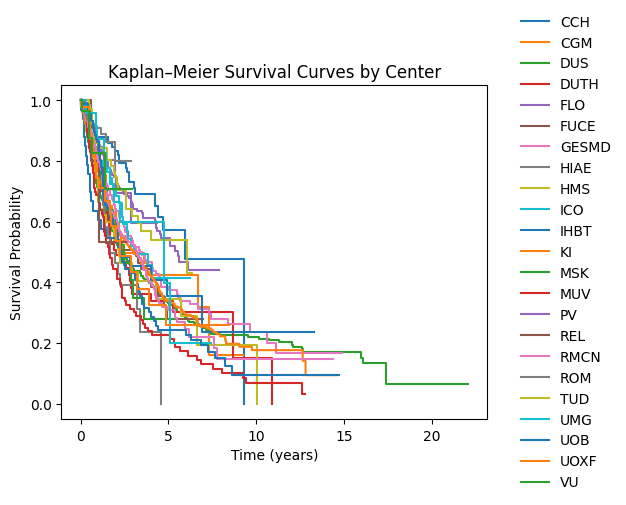

Log-rank global :
   test_statistic             p   -log2(p)
0       95.988817  3.214317e-11  34.856697


In [134]:
# Logrank Test : Les centres ont-ils des courbes de survie différentes ?

# ====== Columns in dataset used======
time_col = "OS_YEARS"
censure_col = "OS_STATUS"
group_col = "CENTER"

# ====== Kaplan survival curve for each center======
kmf = KaplanMeierFitter()

ax = None
for g, dfg in df_eda.dropna(subset=[time_col, censure_col, group_col]).groupby(
    group_col
):
    kmf.fit(durations=dfg[time_col], event_observed=dfg[censure_col], label=str(g))
    ax = kmf.plot(ax=ax, ci_show=False, show_censors=False)

plt.title("Kaplan–Meier Survival Curves by Center")
plt.xlabel("Time (years)")
plt.ylabel("Survival Probability")

# Légende décalée
plt.legend(loc="center left", bbox_to_anchor=(1.05, 0.5), frameon=False)

plt.tight_layout()
plt.show()


# ====== Log-rank global ======
df_valid = df_eda.dropna(subset=[time_col, censure_col, group_col])
res_global = multivariate_logrank_test(
    event_durations=df_valid[time_col],
    groups=df_valid[group_col],
    event_observed=df_valid[censure_col],
)

print("Log-rank global :")
print(res_global.summary)

<div style="background-color:#e8d9ec; color:black; padding:10px; border-radius:5px; border:1px solid #b58db6;">

L’examen visuel des courbes de Kaplan–Meier obtenues pour les différents centres montre que les distributions de survie sont globalement proches, avec quelques variations et croisements entre les courbes, rendant difficile l’identification d’une différence nette. Afin de déterminer si ces différences apparentes traduisent réellement un effet du centre sur la survie, nous cherchons à répondre à la question suivante : le centre influence-t-il la survie des patients ? Pour cela, un test de log-rank global a été réalisé. Le résultat est significatif (χ² = 95.99, p = 3.21×10⁻¹¹), indiquant que les courbes de survie ne sont pas toutes identiques. Ainsi, la variable CENTER pourrait jouer un rôle dans la survie globale, mais cette conclusion reste exploratoire

</div>

### Test2 : 

In [135]:
df_cox = df_eda[[time_col, censure_col] + continuous_vars].dropna().copy()

# On crée une colonne standardisée pour chaque variable
for v in continuous_vars:
    df_cox[v + "_std"] = (df_cox[v] - df_cox[v].mean()) / df_cox[v].std()

cph = CoxPHFitter()

results = []

for v in continuous_vars:

    tmp = df_cox[[time_col, censure_col, v + "_std"]].copy()
    tmp = tmp.rename(columns={v + "_std": "x"})
    cph.fit(tmp, duration_col=time_col, event_col=censure_col)

    # Hazard Ratio
    hr = np.exp(cph.params_["x"])
    pval = cph.summary.loc["x", "p"]

    results.append([v, hr, pval])

df_results = pd.DataFrame(results, columns=["Variable", "HR (1 SD)", "p-value"])
display(df_results)

,Variable,HR (1 SD),p-value
0,BM_BLAST,1.352430,5.464388e-48
1,WBC,1.152222,9.138005e-10
2,ANC,1.114209,2.084128e-06
3,MONOCYTES,1.116185,4.339062e-07
4,HB,0.704071,2.218255e-34
5,PLT,0.724756,2.650755e-19


<div style="background-color:#e8d9ec; color:black; padding:10px; border-radius:5px; border:2px solid #b58db6;">
Le test de Cox univarié effectué nous donne les résultats suivants : les variables BM_BLAST, WBC, ANC et MONOCYTES présentent des Hazard Ratios (HR) significativement supérieurs à 1. Cela signifie que lorsque ces paramètres augmentent d’un écart-type, le risque de décès augmente, indiquant un effet délétère sur la survie.

À l’inverse, les variables HB et PLT ont des HR nettement inférieurs à 1. Une augmentation de ces valeurs est donc associée à une diminution du risque de décès, ce qui traduit un effet protecteur.

Toutes ces associations sont statistiquement significatives (p < 0.05), ce qui confirme que chacune des variables continues étudiées influence la survie, dans des directions opposées selon le paramètre considéré.

</div>

<div style="background-color:#e8d9ec; color:black; padding:10px; border-radius:5px; border:1px solid #b58db6;">

### Test3  : Les groupes cytogénétiques ont-ils des survies différentes ?”
</div>

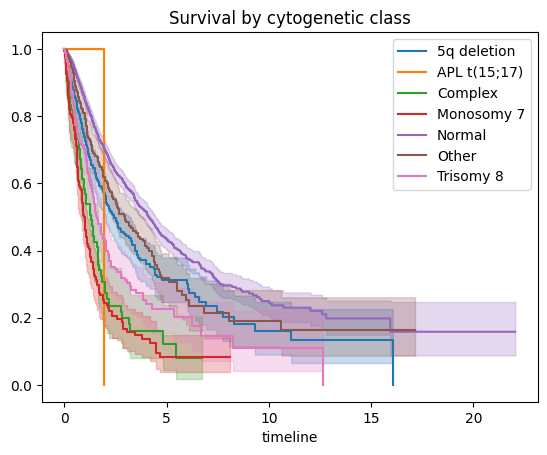

   test_statistic             p    -log2(p)
0       265.66316  1.836916e-54  178.506831
                                   coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z             p   -log2(p)
covariate                                                                                                                                                                        
C(CYTO_CLASS)[T.APL t(15;17)]  0.594448   1.812030  1.003144       -1.371679        2.560574             0.253681            12.943250     0.0  0.592585  5.534592e-01   0.853451
C(CYTO_CLASS)[T.Complex]       0.674891   1.963818  0.154126        0.372809        0.976972             1.451808             2.656400     0.0  4.378827  1.193197e-05  16.354808
C(CYTO_CLASS)[T.Monosomy 7]    0.848980   2.337262  0.118245        0.617224        1.080737             1.853774             2.946849     0.0  7.179827  6.979958e-13  40.381847
C(CYTO_CLASS)[T.Normal

In [136]:
kmf = KaplanMeierFitter()
df_valid = df_eda.dropna(subset=["OS_YEARS", "OS_STATUS", "CYTO_CLASS"])

for g, dfg in df_valid.groupby("CYTO_CLASS"):
    kmf.fit(dfg["OS_YEARS"], dfg["OS_STATUS"], label=g)
    kmf.plot()
plt.title("Survival by cytogenetic class")
plt.show()

# Logrank test
res = multivariate_logrank_test(
    df_valid["OS_YEARS"], df_valid["CYTO_CLASS"], df_valid["OS_STATUS"]
)
print(res.summary)

#
df_temp = df_valid.copy()
cph = CoxPHFitter()
cph.fit(
    df_temp, duration_col="OS_YEARS", event_col="OS_STATUS", formula="C(CYTO_CLASS)"
)

# Récupérer le résumé en DataFrame et l'afficher en texte
summary = cph.summary
print(summary.to_string())

<div style="background-color:#e8d9ec; color:black; padding:10px; border-radius:5px; border:1px solid #b58db6;">

L’analyse de la survie selon les groupes cytogénétiques montre une séparation nette des courbes de Kaplan–Meier, suggérant des différences importantes de pronostic. Le test de log-rank global confirme statistiquement ces observations (p < 10⁻⁵⁰), indiquant que la survie dépend significativement de la classe cytogénétique. Les résultats du modèle de Cox univarié montrent que les groupes Monosomy 7 (HR ≈ 2.31) et Complex (HR ≈ 1.95) présentent un risque significativement accru, tandis que le groupe Normal est associé à une réduction du risque (HR ≈ 0.66). Les groupes Other et Missing ne montrent pas d’effet significatif. Ces résultats confirment le rôle pronostique majeur des anomalies cytogénétiques dans la survie

</div>

## 2/EDA for molecular dataset

In [137]:
display(df_molecular.head(20))
# Size
df_molecular.shape

,ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
0,P100000,11,119149248.0,119149248.0,G,A,CBL,p.C419Y,non_synonymous_codon,0.0830,1308.0
1,P100000,5,131822301.0,131822301.0,G,T,IRF1,p.Y164*,stop_gained,0.0220,532.0
2,P100000,3,77694060.0,77694060.0,G,C,ROBO2,p.?,splice_site_variant,0.4100,876.0
3,P100000,4,106164917.0,106164917.0,G,T,TET2,p.R1262L,non_synonymous_codon,0.4300,826.0
4,P100000,2,25468147.0,25468163.0,ACGAAGAGGGGGTGTTC,A,DNMT3A,p.E505fs*141,frameshift_variant,0.0898,942.0
5,P100001,22,29091725.0,29091725.0,C,T,CHEK2,p.W454*,stop_gained,0.4180,514.0
6,P100001,3,178936091.0,178936091.0,G,A,PIK3CA,p.E545K,non_synonymous_codon,0.1010,558.0
7,P100002,3,178936091.0,178936091.0,G,A,PIK3CA,p.E545K,non_synonymous_codon,0.1970,310.0
8,P100002,17,7579533.0,7579533.0,G,A,TP53,p.Q52*,stop_gained,0.5970,487.0
9,P100004,X,123190080.0,123190081.0,C,CA,STAG2,p.L436fs*5,frameshift_variant,0.4691,1296.0


(10935, 11)

ON remarque que une ligne du dataset moléculaire reprsente une mutation asscoié à un patient donnée, donc un patient peut avoir plusieur mutation et donc  on aura plusieurs lignes par patient. 

Donc on doit résumer les mutations d’un patient en quelques nombres ou indicateurs ce qui nous donnera un patient par ligne afin de pouvoir le merging avec le datatset moléculaire. 

## Number of mutation per patient; Top genes and top effets, VAF distribution

Is ID unique in molecular? False


count    3026.000000
mean        3.613681
std         2.220222
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        17.000000
dtype: float64

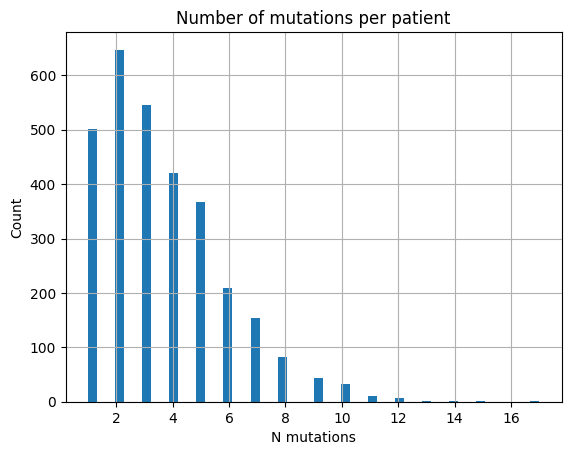

GENE
TET2      1663
ASXL1      951
SF3B1      775
DNMT3A     604
RUNX1      578
SRSF2      577
TP53       487
STAG2      376
U2AF1      288
EZH2       252
CBL        228
BCOR       213
NRAS       200
ZRSR2      196
DDX41      185
IDH2       166
CUX1       160
NF1        159
PHF6       149
KRAS       133
Name: count, dtype: int64

EFFECT
non_synonymous_codon            5471
frameshift_variant              2877
stop_gained                     1673
splice_site_variant              512
inframe_codon_loss               168
PTD                               89
inframe_codon_gain                55
ITD                               26
initiator_codon_change            24
2KB_upstream_variant              12
complex_change_in_transcript      11
3_prime_UTR_variant                5
inframe_variant                    4
stop_lost                          4
synonymous_codon                   3
Name: count, dtype: int64

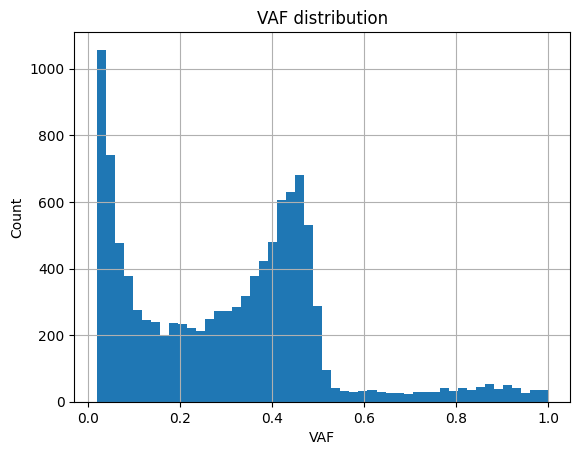

In [138]:
print("Is ID unique in molecular?", df_molecular["ID"].is_unique)

mut_per_patient = df_molecular.groupby("ID").size()
display(mut_per_patient.describe())

plt.figure()
mut_per_patient.hist(bins=50)
plt.title("Number of mutations per patient")
plt.xlabel("N mutations")
plt.ylabel("Count")
plt.show()

top_genes_eda = df_molecular["GENE"].value_counts().head(20)
top_effects_eda = df_molecular["EFFECT"].value_counts().head(15)
display(top_genes_eda)
display(top_effects_eda)

plt.figure()
df_molecular["VAF"].dropna().hist(bins=50)
plt.title("VAF distribution")
plt.xlabel("VAF")
plt.ylabel("Count")
plt.show()

Cette figure montre un profil très classique en mutations somatiques :

- Beaucoup de VAF faibles (≈ 0.02–0.10) : mutations présentes dans une petite fraction de cellules (sous-clones) ou mutations moins dominantes.

- Un gros “paquet” autour de 0.4–0.5 : mutations clonalement dominantes (souvent proches d’un hétérozygote dans une population tumorale relativement pure, d’où ~0.5).

- Une queue vers 0.8–1.0 : possible perte d’allèle, forte clonalité, ou biais de mesure pour certains loci.

# Preprocessing

## Outliers

In [139]:
df_eda.describe()

,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,OS_YEARS,OS_STATUS
count,3214.000000,3051.000000,3130.000000,2722.000000,3213.000000,3199.000000,3173.000000,3173.000000
mean,5.982545,6.535164,3.264735,0.955868,9.893549,167.048900,2.480713,0.504255
std,7.615439,10.247219,5.237043,2.666478,2.041158,149.477031,2.588259,0.500061
min,0.000000,0.200000,0.000000,0.000000,4.000000,2.000000,0.000000,0.000000
25%,1.000000,2.700000,1.000000,0.150000,8.500000,65.500000,0.652055,0.000000
50%,3.000000,4.100000,2.000000,0.370000,9.700000,123.000000,1.652055,1.000000
75%,8.000000,6.655000,3.690000,0.783000,11.200000,229.500000,3.572603,1.000000
max,91.000000,154.400000,109.620000,44.200000,16.600000,1451.000000,22.043836,1.000000


#### Identification of univariate outliers

In [140]:
def iqr_outliers_detection(df, feature, factor=1.5):
    """
    Detection of outliers using the IQR method.

    Args:
        df (DataFrame): Dataset
        feature (str) : column_name
        factor (float) : multiplicatif factor .Default =1.5


    Returns
        outliers (DataFrame) :  Dataframe containing the outliers related to the feature
        bounds : dict
            Dico containing Q1, Q3, IQR, bornes min/max
    """

    s = df[feature].dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - factor * iqr
    upper = q3 + factor * iqr

    outliers = df.query(f"{feature} < @lower or {feature} > @upper")

    bounds = {
        "min": df[feature].min(),
        "max": df[feature].max(),
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
    }

    return outliers, bounds

In [141]:
for feature in continuous_vars:
    outliers, bounds = iqr_outliers_detection(df_eda, feature)

    print(f"#-----{feature}-----")
    print("Outliers number :", outliers.shape[0])
    display(bounds)
    # display(outliers.head())
    print()

#-----BM_BLAST-----
Outliers number : 181


{'min': np.float64(0.0),
 'max': np.float64(91.0),
 'IQR': np.float64(7.0),
 'lower_bound': np.float64(-9.5),
 'upper_bound': np.float64(18.5)}


#-----WBC-----
Outliers number : 229


{'min': np.float64(0.2),
 'max': np.float64(154.4),
 'IQR': np.float64(3.955),
 'lower_bound': np.float64(-3.2325),
 'upper_bound': np.float64(12.5875)}


#-----ANC-----
Outliers number : 220


...

{'min': np.float64(0.0),
 'max': np.float64(44.2),
 'IQR': np.float64(0.633),
 'lower_bound': np.float64(-0.7995),
 'upper_bound': np.float64(1.7325)}


#-----HB-----
Outliers number : 32


{'min': np.float64(4.0),
 'max': np.float64(16.6),
 'IQR': np.float64(2.6999999999999993),
 'lower_bound': np.float64(4.450000000000001),
 'upper_bound': np.float64(15.249999999999998)}


#-----PLT-----
Outliers number : 130


{'min': np.float64(2.0),
 'max': np.float64(1451.0),
 'IQR': np.float64(164.0),
 'lower_bound': np.float64(-180.5),
 'upper_bound': np.float64(475.5)}

<div style="background-color:#e8d9ec; color:black; padding:10px; border-radius:5px; border:1px solid #b58db6;">

Many biological variables exhibit extreme values, but these are clinically plausible, so we will analyze them in more detail in the next phase.
</div>

#### Identification of multivariate outliers

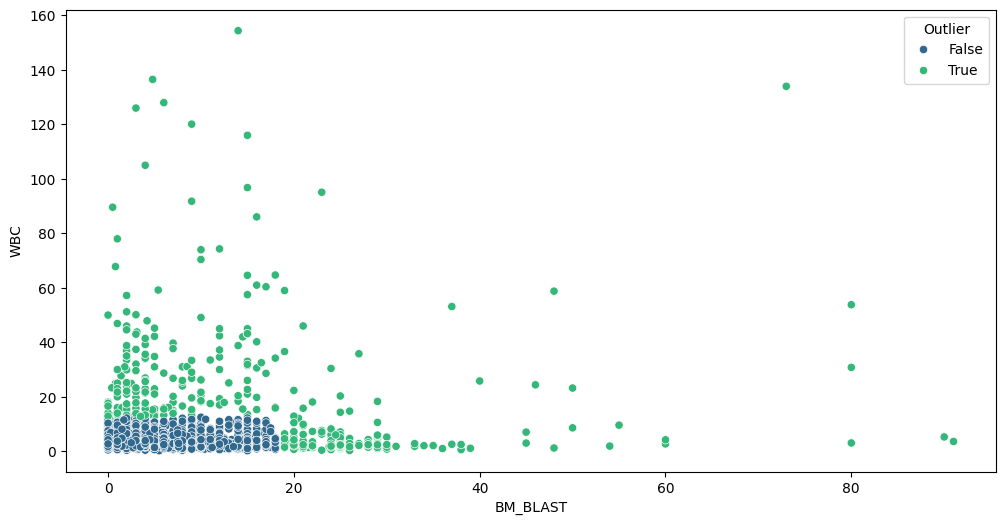

In [142]:
# Détecter les outliers pour les colonnes 'RM' et 'PRICE'
outliers_blast, b1 = iqr_outliers_detection(df_eda, "BM_BLAST")
outliers_wbc, b2 = iqr_outliers_detection(df_eda, "WBC")

# Ajouter une colonne pour indiquer si la valeur est extrême
df_eda["Outlier"] = False
df_eda.loc[outliers_blast.index, "Outlier"] = True
df_eda.loc[outliers_wbc.index, "Outlier"] = True

# Créer un nuage de points (scatter plot) avec Seaborn en mettant en évidence les valeurs extrêmes
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_eda, x="BM_BLAST", y="WBC", hue="Outlier", palette="viridis")
# plt.xlabel('Nombre moyen de pièces par logement')
# plt.ylabel('Prix des maisons')
# plt.title("Nuage de points entre le nombre de pièces et le prix des maisons à Boston (valeurs extrêmes en couleur)")
plt.show()

In [143]:
df_eda

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,OS_YEARS,OS_STATUS,CYTO_CLASS,Outlier
0,P132697,MSK,14.0,2.80,0.20,0.70,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",1.115068,1.0,Other,False
1,P132698,MSK,1.0,7.40,2.40,0.10,11.6,42.0,"46,xx",4.928767,0.0,Normal,False
2,P116889,MSK,15.0,3.70,2.10,0.10,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",2.043836,0.0,Other,False
3,P132699,MSK,1.0,3.90,1.90,0.10,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",2.476712,1.0,Other,False
4,P132700,MSK,6.0,128.00,9.70,0.90,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",3.145205,0.0,Other,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3318,P121828,VU,1.0,3.70,2.53,0.53,8.9,499.0,"46,xy[20]",NaN,NaN,Normal,False
3319,P121829,VU,0.0,4.20,2.40,0.22,10.6,49.0,"46,xy,del(13)(q12q14)[1]/45,x,-y,del(13)(q12q1...",NaN,NaN,Other,False
3320,P121830,VU,0.0,1.80,0.55,0.29,9.4,86.0,"46,xy,del(20)(q11.2q13.1)[4]/45,xy,idem,-7[16]",1.997260,0.0,Monosomy 7,False
3321,P121853,VU,5.0,1.37,0.37,0.11,11.4,102.0,"46,xx,del(1)(p34)[5]/45,xx,sl,-18[12]/46,xx,sd...",0.095890,1.0,Trisomy 8,False


In [144]:
df

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,OS_YEARS,OS_STATUS
0,P132697,MSK,14.0,2.80,0.20,0.70,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",1.115068,1.0
1,P132698,MSK,1.0,7.40,2.40,0.10,11.6,42.0,"46,xx",4.928767,0.0
2,P116889,MSK,15.0,3.70,2.10,0.10,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",2.043836,0.0
3,P132699,MSK,1.0,3.90,1.90,0.10,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",2.476712,1.0
4,P132700,MSK,6.0,128.00,9.70,0.90,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",3.145205,0.0
...,...,...,...,...,...,...,...,...,...,...,...
3318,P121828,VU,1.0,3.70,2.53,0.53,8.9,499.0,"46,xy[20]",NaN,NaN
3319,P121829,VU,0.0,4.20,2.40,0.22,10.6,49.0,"46,xy,del(13)(q12q14)[1]/45,x,-y,del(13)(q12q1...",NaN,NaN
3320,P121830,VU,0.0,1.80,0.55,0.29,9.4,86.0,"46,xy,del(20)(q11.2q13.1)[4]/45,xy,idem,-7[16]",1.997260,0.0
3321,P121853,VU,5.0,1.37,0.37,0.11,11.4,102.0,"46,xx,del(1)(p34)[5]/45,xx,sl,-18[12]/46,xx,sd...",0.095890,1.0


In [145]:
from sklearn.ensemble import IsolationForest

# Appliquer l'Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
df_clinical_numeric = df.select_dtypes(exclude=["object"])
outlier_labels = iso_forest.fit_predict(df_clinical_numeric)

# Ajouter les labels d'anomalie au DataFrame
df["Outlier_1"] = outlier_labels

# Afficher les outliers
outliers = df[df["Outlier_1"] == -1]
print("Outliers detected:")
print(outliers.shape[0])
display(outliers)

Outliers detected:
333


,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,OS_YEARS,OS_STATUS,Outlier_1
4,P132700,MSK,6.0,128.00,9.70,0.900,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",3.145205,0.0,-1
5,P132701,MSK,3.0,15.80,12.60,0.880,8.0,492.0,"46,xx[20]",2.013699,1.0,-1
13,P132709,MSK,6.0,9.00,2.30,1.200,7.2,842.0,"47,xy,+8[16]/46,xy[2]",1.054795,1.0,-1
14,P106410,MSK,4.0,4.70,2.60,0.100,12.8,716.0,"47,xx,+8[20]",4.608219,0.0,-1
35,P132728,MSK,2.0,44.90,40.10,2.300,8.2,14.0,"47,xy,+14[9]",1.284932,1.0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...
3228,P118256,UOB,2.0,25.20,17.14,3.780,9.2,85.0,"46,xx,del(5)(q13q33),der(5)inv(5)(p15q13)[10]",0.613699,1.0,-1
3232,P118260,UOB,4.0,2.11,0.92,0.095,6.4,558.0,"5q-;t(2;11)[8]40%;t(2;11)[9];46,xx[3]",7.013699,0.0,-1
3272,P102729,UOXF,1.7,11.50,6.90,NaN,8.1,634.0,"46,xy[10]",5.583562,0.0,-1
3274,P102731,UOXF,1.0,0.60,0.10,NaN,4.5,34.0,"45,x,-y[5]",1.041096,1.0,-1


In [146]:
from sklearn.ensemble import IsolationForest

features = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]

iso = IsolationForest(contamination=0.01, random_state=42)
df_eda["IF_OUTLIER"] = iso.fit_predict(df_eda[features])

# -1 = anomalie, 1 = normal
outliers_df = df_eda[df_eda["IF_OUTLIER"] == -1]
print(
    f"L'isolation forest avec le paramètre de contamination de 0.01 (donc 1%) a détecter {outliers.shape[0]} outliers"
)
outliers

L'isolation forest avec le paramètre de contamination de 0.01 (donc 1%) a détecter 333 outliers


,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,OS_YEARS,OS_STATUS,Outlier_1
4,P132700,MSK,6.0,128.00,9.70,0.900,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",3.145205,0.0,-1
5,P132701,MSK,3.0,15.80,12.60,0.880,8.0,492.0,"46,xx[20]",2.013699,1.0,-1
13,P132709,MSK,6.0,9.00,2.30,1.200,7.2,842.0,"47,xy,+8[16]/46,xy[2]",1.054795,1.0,-1
14,P106410,MSK,4.0,4.70,2.60,0.100,12.8,716.0,"47,xx,+8[20]",4.608219,0.0,-1
35,P132728,MSK,2.0,44.90,40.10,2.300,8.2,14.0,"47,xy,+14[9]",1.284932,1.0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...
3228,P118256,UOB,2.0,25.20,17.14,3.780,9.2,85.0,"46,xx,del(5)(q13q33),der(5)inv(5)(p15q13)[10]",0.613699,1.0,-1
3232,P118260,UOB,4.0,2.11,0.92,0.095,6.4,558.0,"5q-;t(2;11)[8]40%;t(2;11)[9];46,xx[3]",7.013699,0.0,-1
3272,P102729,UOXF,1.7,11.50,6.90,NaN,8.1,634.0,"46,xy[10]",5.583562,0.0,-1
3274,P102731,UOXF,1.0,0.60,0.10,NaN,4.5,34.0,"45,x,-y[5]",1.041096,1.0,-1


In [147]:
from sklearn.ensemble import IsolationForest

continuous_vars = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]

# On prend uniquement les lignes sans NA sur ces variables
X = df_eda[continuous_vars].dropna()

iso = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
iso.fit(X)

# prédictions : 1 = inlier, -1 = outlier
labels = iso.predict(X)
scores = iso.decision_function(X)  # plus petit -> plus "anormal"

# On remet dans le DataFrame original
df_eda_iforest = df_eda.copy()
df_eda_iforest["IF_outlier"] = False
df_eda_iforest["IF_score"] = float("nan")

df_eda_iforest.loc[X.index, "IF_outlier"] = labels == -1
df_eda_iforest.loc[X.index, "IF_score"] = scores

print("Nombre d'outliers (Isolation Forest) :", df_eda_iforest["IF_outlier"].sum())

# Dataset "nettoyé" en enlevant les outliers IF
df_eda_if_clean = df_eda_iforest.loc[~df_eda_iforest["IF_outlier"]].copy()

Nombre d'outliers (Isolation Forest) : 268


In [148]:
df_eda.nlargest(10, "WBC")[["WBC", "OS_YEARS", "OS_STATUS"]]

,WBC,OS_YEARS,OS_STATUS
1427,154.40,0.424658,1.0
1219,136.53,0.515068,0.0
1837,134.00,0.041096,1.0
4,128.00,3.145205,0.0
2432,126.00,0.841096,1.0
225,120.10,0.961644,0.0
2508,116.00,1.227397,1.0
2034,105.00,0.087671,1.0
2302,96.80,0.301370,1.0
1549,95.10,0.189041,1.0


## Missing Values 

---Missing values:
ID                0
CENTER            0
BM_BLAST         79
WBC             229
ANC             141
MONOCYTES       544
HB               75
PLT              86
CYTOGENETICS    348
OS_YEARS          0
OS_STATUS         0
CYTO_CLASS      348
dtype: int64


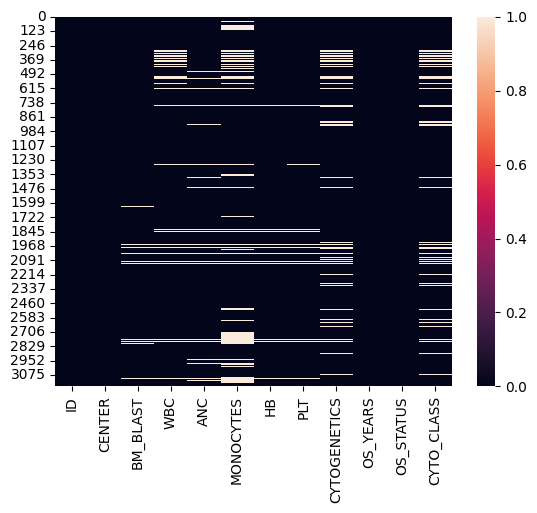

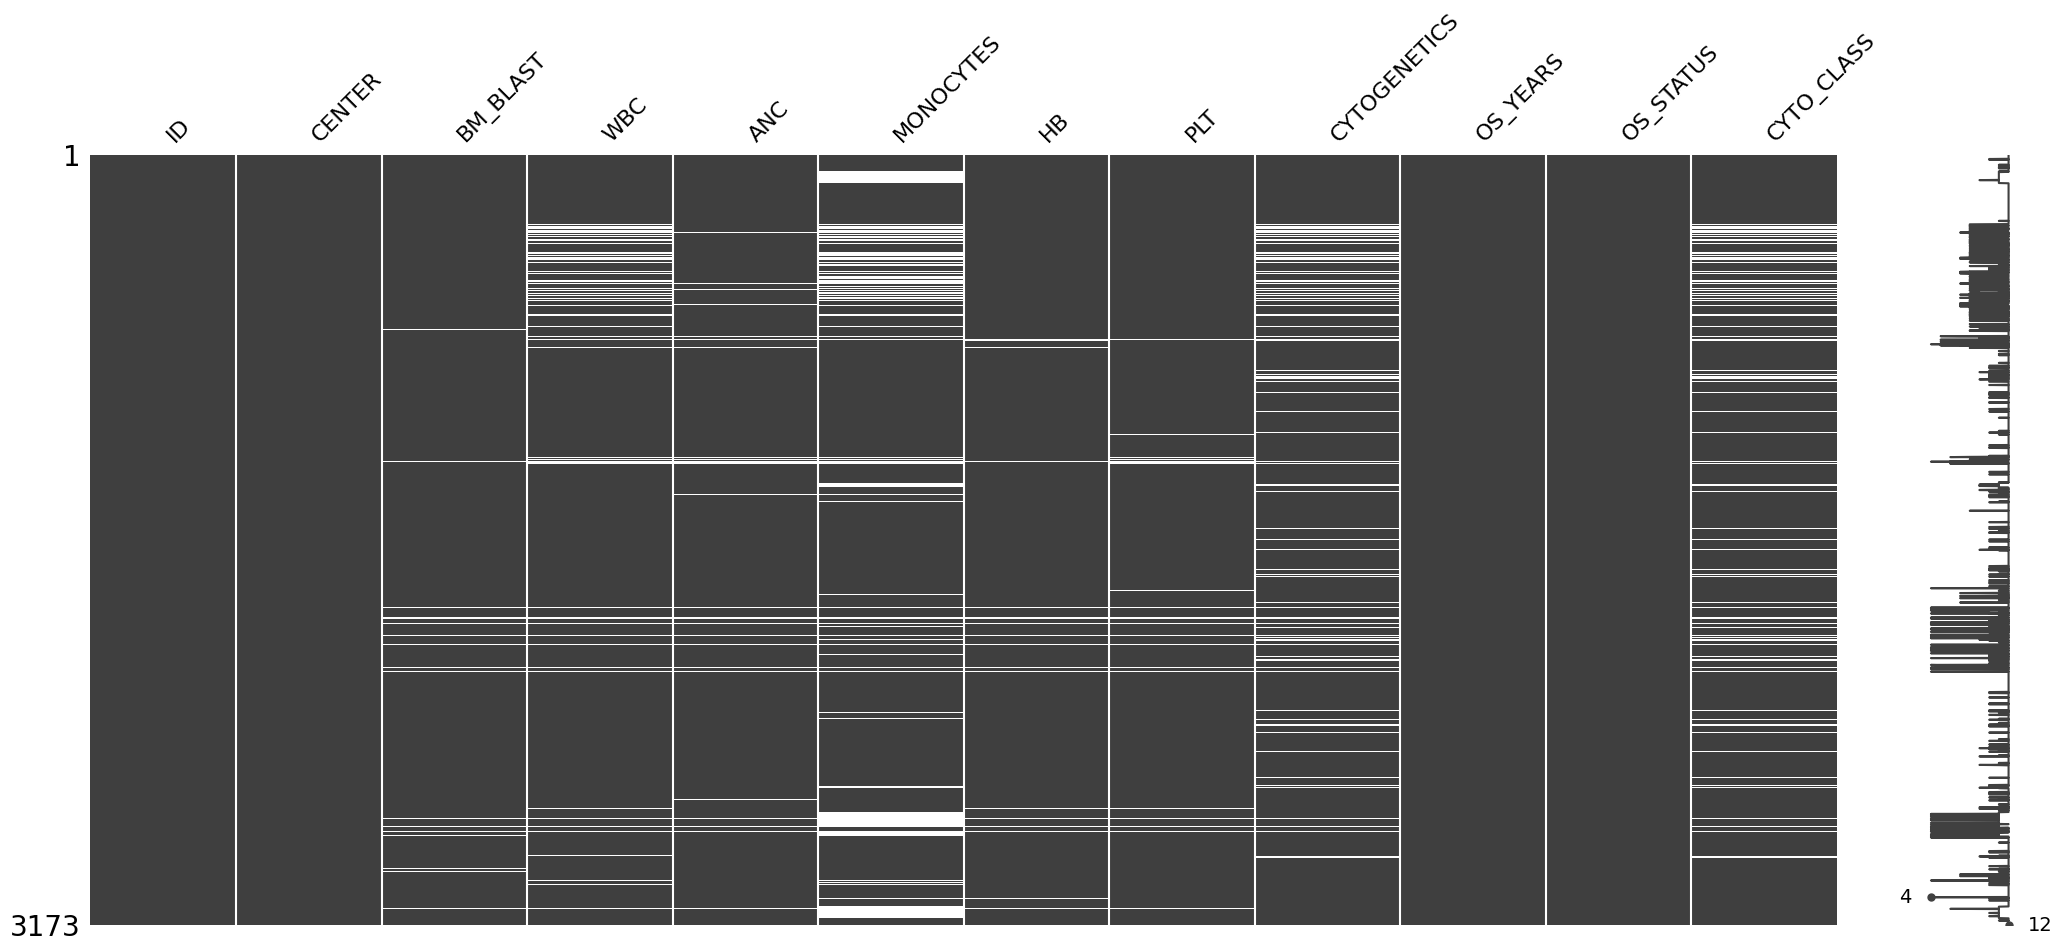

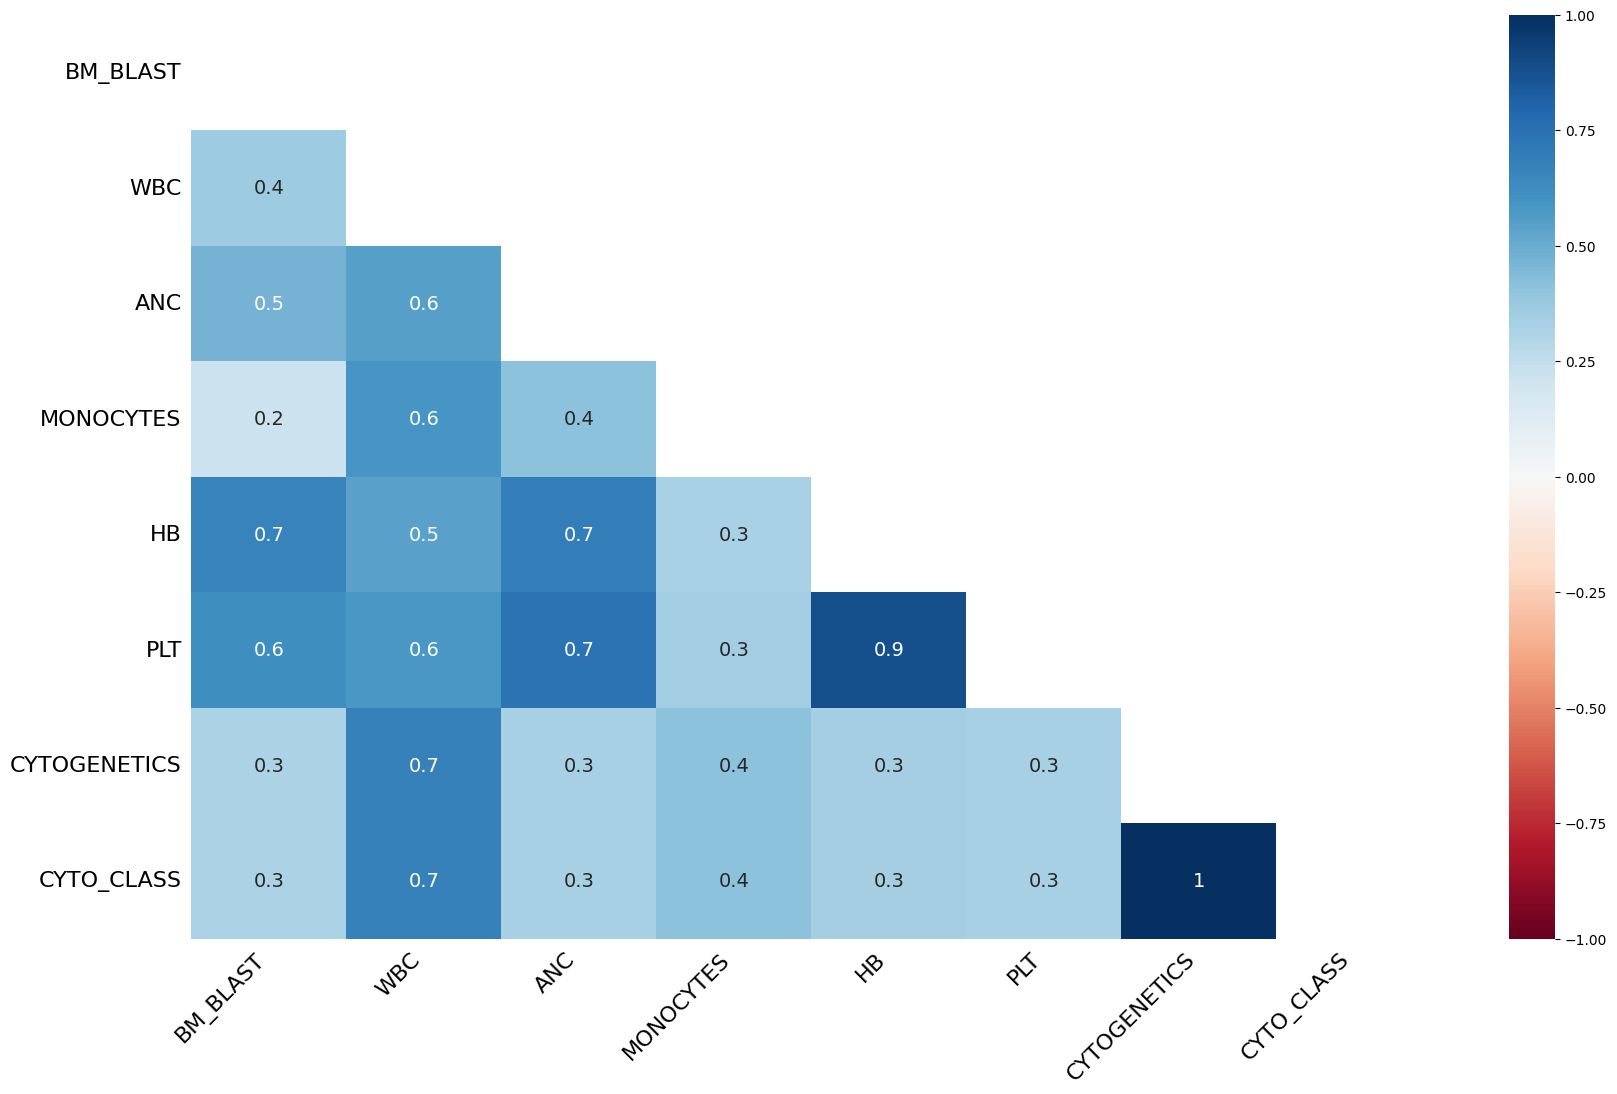

,Missing Values,Percentage
ID,0,0.000000
CENTER,0,0.000000
BM_BLAST,79,2.489757
WBC,229,7.217145
ANC,141,4.443744
MONOCYTES,544,17.144658
HB,75,2.363694
PLT,86,2.710369
CYTOGENETICS,348,10.967539
OS_YEARS,0,0.000000


In [149]:
# 1)dataset
df_y_clean = df_y.dropna(subset=["OS_YEARS", "OS_STATUS"]).copy()
df_model = df_clinical.merge(df_y_clean, on="ID", how="inner").copy()
df_model["CYTO_CLASS"] = df_model["CYTOGENETICS"].apply(cytogenetic_group)

num_cols_clin = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]
cat_cols = ["CENTER", "CYTO_CLASS"]

# 2) Missingness diagnostic
print("---Missing values:")
print(df_model.isna().sum())

sns.heatmap(df_model.isna())
plt.show()

msno.matrix(df_model)
plt.show()

msno.heatmap(df_model)
plt.show()

missing_table = pd.DataFrame(
    {
        "Missing Values": df_model.isnull().sum(),
        "Percentage": 100 * df_model.isnull().sum() / len(df_model),
    }
)
display(missing_table)

Imputation dataset: 3075 / 3173
ID                0
CENTER            0
BM_BLAST         27
WBC             131
ANC              43
MONOCYTES       446
HB                4
PLT               4
CYTOGENETICS    270
OS_YEARS          0
OS_STATUS         0
CYTO_CLASS      270
dtype: int64


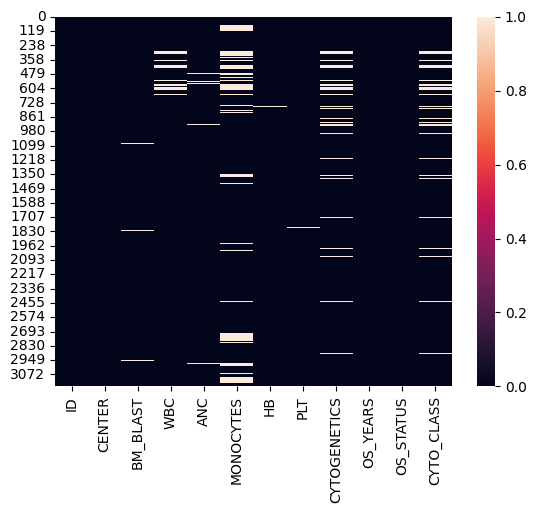

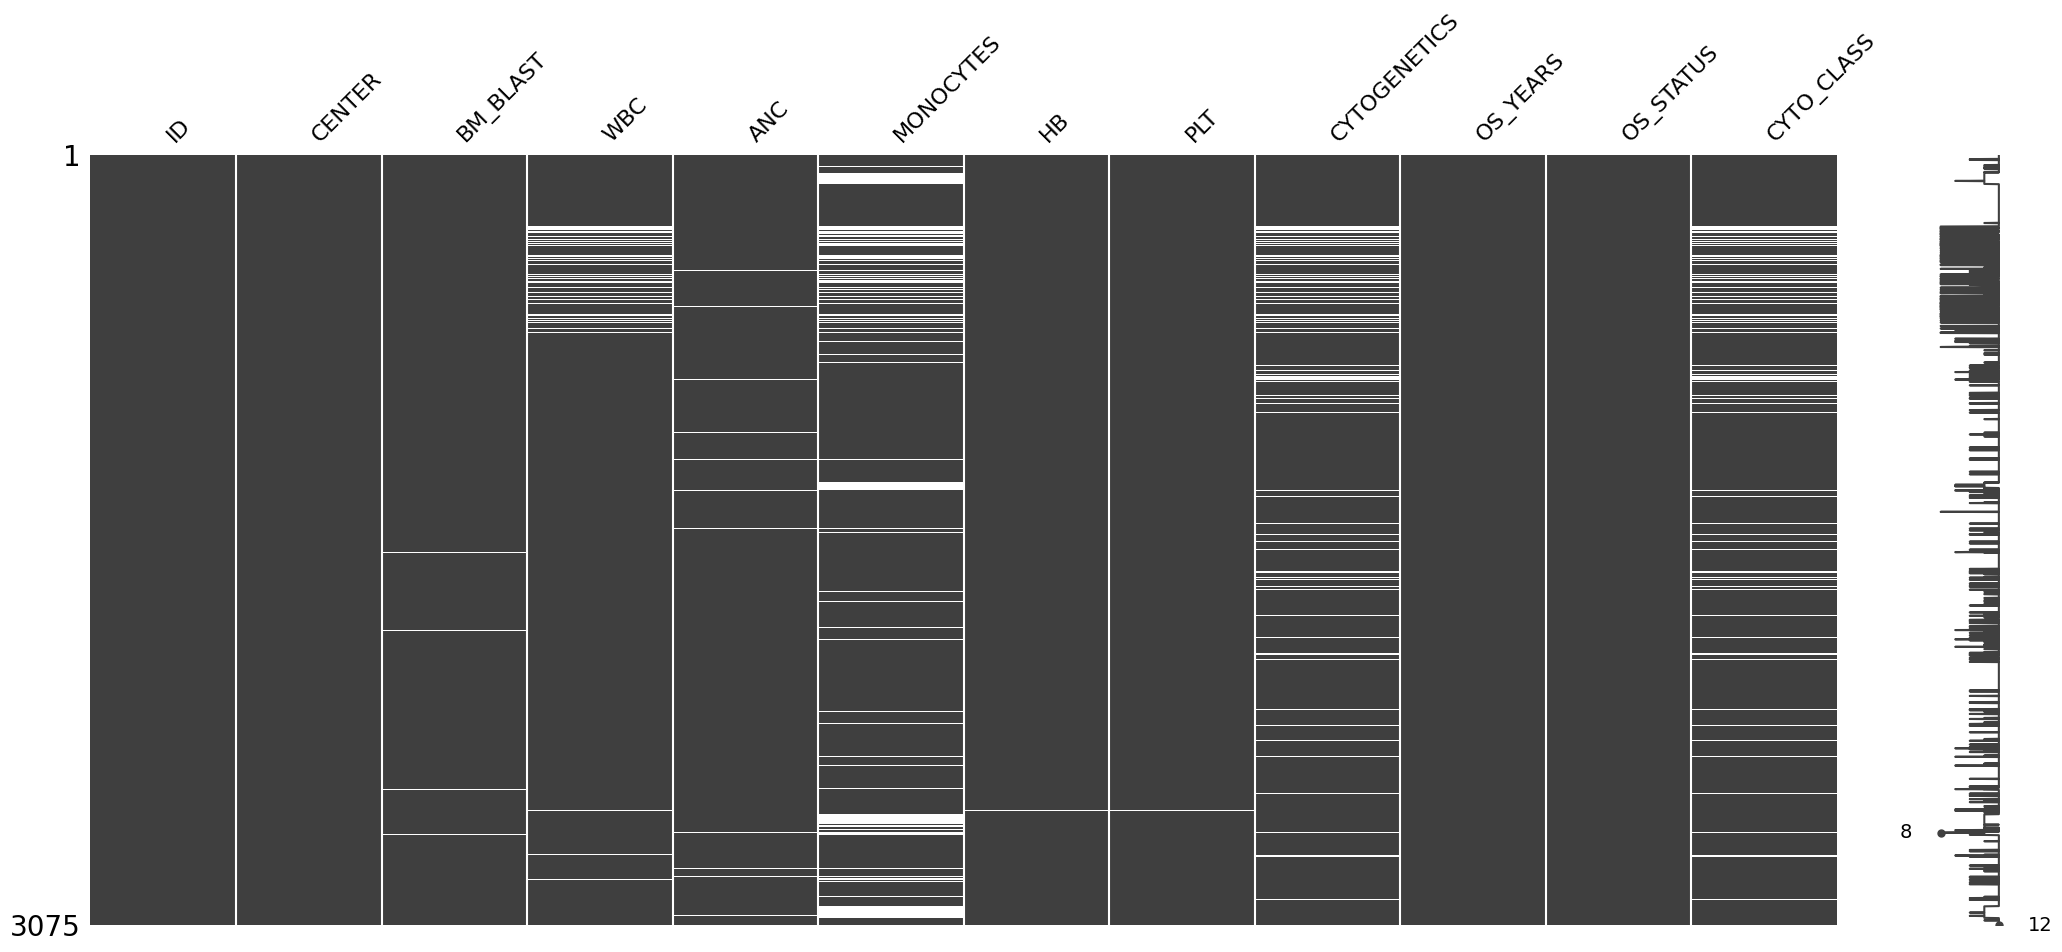

In [150]:
# Filter
num_cols = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]
cat_cols = ["CENTER", "CYTO_CLASS"]

row_missing = df_model[num_cols + ["CYTO_CLASS"]].isna().sum(axis=1)
df_imp = df_model[row_missing <= 3].copy()
print("Imputation dataset:", len(df_imp), "/", len(df_model))

# Diagnostic missingness après filtrage
print(df_imp.isna().sum())

sns.heatmap(df_imp.isna())
plt.show()

msno.matrix(df_imp)
plt.show()

## Feature engineering

"""
L’EDA montre (i) des distributions très asymétriques avec valeurs extrêmes pour WBC/ANC/MONOCYTES/PLT, et (ii) une forte corrélation entre WBC, ANC et MONOCYTES, suggérant une redondance. Pour extraire une information complémentaire et mieux caractériser le profil hématologique, nous avons introduit des variables dérivées décrivant la composition leucocytaire : ANC/WBC et MONOCYTES/WBC, interprétées comme des proportions de sous-populations. Nous avons également ajouté des indicateurs de valeurs extrêmes (quantiles) afin de capturer un effet de seuil observé visuellement, ainsi que des indicateurs de valeurs manquantes car le pattern de NaN n’est pas aléatoire et peut refléter des pratiques de centre ou des situations cliniques particulières. Enfin, la variable CENTER est conservée car le test global de log-rank indique des distributions de survie différentes selon les centres ; les centres rares sont regroupés pour limiter le sur-apprentissage."""

In [151]:
# Missing indicators

"""
for c in ["WBC","ANC","MONOCYTES","PLT"]:
    df_imp[c+"_miss"] = df_imp[c].isna().astype(int)

# New variables (ratios)
eps = 1e-6
df_imp["RATIO_ANC_WBC"]  = df_imp["ANC"] / (df_imp["WBC"] + eps)
df_imp["RATIO_MONO_WBC"] = df_imp["MONOCYTES"] / (df_imp["WBC"] + eps)

min_center_count = 30
counts = df_imp["CENTER"].value_counts()
rare_centers = counts[counts < min_center_count].index

df_imp["CENTER"] = df_imp["CENTER"].where(~df_imp["CENTER"].isin(rare_centers), "OtherCenter")

num_cols_fe = num_cols + ["RATIO_ANC_WBC","RATIO_MONO_WBC","WBC_miss","ANC_miss","MONOCYTES_miss","PLT_miss"]
cat_cols_fe = ["CENTER","CYTO_CLASS"]
feat_cols_fe = num_cols_fe + cat_cols_fe

"""

'\nfor c in ["WBC","ANC","MONOCYTES","PLT"]:\n    df_imp[c+"_miss"] = df_imp[c].isna().astype(int)\n\n# New variables (ratios)\neps = 1e-6\ndf_imp["RATIO_ANC_WBC"]  = df_imp["ANC"] / (df_imp["WBC"] + eps)\ndf_imp["RATIO_MONO_WBC"] = df_imp["MONOCYTES"] / (df_imp["WBC"] + eps)\n\nmin_center_count = 30\ncounts = df_imp["CENTER"].value_counts()\nrare_centers = counts[counts < min_center_count].index\n\ndf_imp["CENTER"] = df_imp["CENTER"].where(~df_imp["CENTER"].isin(rare_centers), "OtherCenter")\n\nnum_cols_fe = num_cols + ["RATIO_ANC_WBC","RATIO_MONO_WBC","WBC_miss","ANC_miss","MONOCYTES_miss","PLT_miss"]\ncat_cols_fe = ["CENTER","CYTO_CLASS"]\nfeat_cols_fe = num_cols_fe + cat_cols_fe\n\n'

## Pipeline (Clinique only)

In [152]:
def log1p_cols(X):
    X = X.copy()
    for c in ["WBC", "ANC", "MONOCYTES", "PLT"]:
        if c in X.columns:
            X[c] = np.log1p(X[c])
    return X


num_pipe = Pipeline(
    steps=[
        ("log1p", FunctionTransformer(log1p_cols, feature_names_out="one-to-one")),
        ("scaler", StandardScaler()),
        ("knn", KNNImputer(n_neighbors=5, weights="distance")),
    ]
)

cat_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Other")),
        (
            "onehot",
            OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

preprocess_clin = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ]
)

## Molecular preprocessing 

In [153]:
df_mol = df_molecular.copy()

top_effects = df_mol["EFFECT"].value_counts().head(10).index
top_genes = df_mol["GENE"].value_counts().head(30).index

mol_agg = (
    df_mol.groupby("ID")
    .agg(
        N_MUT=("GENE", "size"),
        N_GENES=("GENE", "nunique"),
        VAF_MEAN=("VAF", "mean"),
        VAF_MAX=("VAF", "max"),
        DEPTH_MEAN=("DEPTH", "mean"),
        DEPTH_MAX=("DEPTH", "max"),
    )
    .reset_index()
)

df_mol["EFFECT_GRP"] = df_mol["EFFECT"].where(
    df_mol["EFFECT"].isin(top_effects), "OTHER_EFFECT"
)
effect_counts = (
    df_mol.pivot_table(
        index="ID", columns="EFFECT_GRP", values="GENE", aggfunc="size", fill_value=0
    )
    .add_prefix("EFFECT_")
    .reset_index()
)

gene_flags = (
    df_mol.assign(flag=1)
    .pivot_table(index="ID", columns="GENE", values="flag", aggfunc="max", fill_value=0)
    .reindex(columns=top_genes, fill_value=0)
    .add_prefix("GENE_")
    .reset_index()
)

df_mol_features = mol_agg.merge(effect_counts, on="ID", how="left").merge(
    gene_flags, on="ID", how="left"
)
df_mol_features["HAS_MOL_DATA"] = 1
df_mol_features = df_mol_features.fillna(0)

print("df_mol_features:", df_mol_features.shape)
df_mol_features.head()

df_mol_features: (3026, 49)


,ID,N_MUT,N_GENES,VAF_MEAN,VAF_MAX,DEPTH_MEAN,DEPTH_MAX,EFFECT_2KB_upstream_variant,EFFECT_ITD,EFFECT_OTHER_EFFECT,...,GENE_JAK2,GENE_MLL,GENE_PTPN11,GENE_CEBPA,GENE_IDH1,GENE_ETV6,GENE_ETNK1,GENE_MPL,GENE_SH2B3,HAS_MOL_DATA
0,P100000,6,6,0.3013,0.7730,834.5,1308.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,P100001,2,2,0.2595,0.4180,536.0,558.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,P100002,2,2,0.3970,0.5970,398.5,487.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,P100004,1,1,0.4691,0.4691,1296.0,1296.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,P100006,5,5,0.1693,0.3720,591.4,884.0,0,0,0,...,1,0,0,0,0,0,1,0,0,1


8) Merge clinique + moléculaire → df_train_full

In [154]:
df_train_full = df_imp.merge(df_mol_features, on="ID", how="left")

mol_cols = [c for c in df_mol_features.columns if c != "ID"]
df_train_full[mol_cols] = df_train_full[mol_cols].fillna(0)

df_train_full["HAS_MOL_DATA"] = df_train_full["HAS_MOL_DATA"].astype(int)

print("df_train_full:", df_train_full.shape)

df_train_full: (3075, 60)


## Preprocess pipeline (Clinical dataset and molecular dataset)

In [155]:
num_cols_full = num_cols_clin + mol_cols
feat_cols_full = num_cols_full + cat_cols


def log1p_full(X):
    X = X.copy()
    cols_to_log = [
        "WBC",
        "ANC",
        "MONOCYTES",
        "PLT",
        "N_MUT",
        "N_GENES",
        "DEPTH_MAX",
        "DEPTH_MEAN",
    ]
    for c in cols_to_log:
        if c in X.columns:
            X[c] = np.log1p(X[c])
    return X


num_pipe_full = Pipeline(
    steps=[
        ("log1p", FunctionTransformer(log1p_full, feature_names_out="one-to-one")),
        ("scaler", StandardScaler()),
        ("knn", KNNImputer(n_neighbors=5, weights="distance")),
    ]
)

preprocess_full = ColumnTransformer(
    transformers=[
        ("num", num_pipe_full, num_cols_full),
        ("cat", cat_pipe, cat_cols),
    ]
)

# Modelisation & Evaluation 

In [100]:
def run_gridsearch(df_train, feat_cols, preprocess, n_jobs=2):
    X = df_train[feat_cols].copy()
    y = Surv.from_arrays(
        event=df_train["OS_STATUS"].astype(bool).values,
        time=df_train["OS_YEARS"].values,
    )

    pipe = Pipeline([("prep", preprocess), ("model", CoxPHSurvivalAnalysis())])

    def cindex_scorer(estimator, X, y):
        pred = estimator.predict(X)
        return concordance_index_censored(y["event"], y["time"], pred)[0]

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    param_grid = [
        {"model": [CoxPHSurvivalAnalysis()], "model__alpha": [1e-4, 1e-3, 1e-2]},
        {
            "model": [RandomSurvivalForest(random_state=42, n_jobs=n_jobs)],
            "model__n_estimators": [200],
            "model__min_samples_leaf": [5, 10],
            "model__min_samples_split": [10],
            "model__max_features": ["sqrt"],
        },
    ]

    gs = GridSearchCV(
        pipe, param_grid=param_grid, scoring=cindex_scorer, cv=cv, n_jobs=n_jobs
    )
    gs.fit(X, y)

    print("Best CV C-index:", gs.best_score_)
    print("Best model:", type(gs.best_estimator_.named_steps["model"]).__name__)
    print("Best params:", gs.best_params_)

    return gs.best_estimator_, gs.best_score_

In [101]:
print("=== Clinique only ===")
best_clin, score_clin = run_gridsearch(
    df_imp, num_cols_clin + cat_cols, preprocess_clin
)

print("\n=== Clinique + Molecular ===")
best_full, score_full = run_gridsearch(df_train_full, feat_cols_full, preprocess_full)

print("\nComparison:")
print("Clinique only CV:", score_clin)
print("Clinique+Mol  CV:", score_full)

=== Clinique only ===


/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categ

Best CV C-index: 0.7133314037697394
Best model: RandomSurvivalForest
Best params: {'model': RandomSurvivalForest(n_jobs=2, random_state=42), 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 10, 'model__n_estimators': 200}

=== Clinique + Molecular ===


/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categ

Best CV C-index: 0.7405451945586913
Best model: RandomSurvivalForest
Best params: {'model': RandomSurvivalForest(n_jobs=2, random_state=42), 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 10, 'model__n_estimators': 200}

Comparison:
Clinique only CV: 0.7133314037697394
Clinique+Mol  CV: 0.7405451945586913


In [ ]:
def make_mol_features(df_molecular, K=30, top_effects_n=10):
    df_mol = df_molecular.copy()

    top_effects = df_mol["EFFECT"].value_counts().head(top_effects_n).index
    top_genes = df_mol["GENE"].value_counts().head(K).index

    mol_agg = (
        df_mol.groupby("ID")
        .agg(
            N_MUT=("GENE", "size"),
            N_GENES=("GENE", "nunique"),
            VAF_MEAN=("VAF", "mean"),
            VAF_MAX=("VAF", "max"),
            DEPTH_MEAN=("DEPTH", "mean"),
            DEPTH_MAX=("DEPTH", "max"),
        )
        .reset_index()
    )

    df_mol["EFFECT_GRP"] = df_mol["EFFECT"].where(
        df_mol["EFFECT"].isin(top_effects), "OTHER_EFFECT"
    )
    effect_counts = (
        df_mol.pivot_table(
            index="ID",
            columns="EFFECT_GRP",
            values="GENE",
            aggfunc="size",
            fill_value=0,
        )
        .add_prefix("EFFECT_")
        .reset_index()
    )

    gene_flags = (
        df_mol.assign(flag=1)
        .pivot_table(
            index="ID", columns="GENE", values="flag", aggfunc="max", fill_value=0
        )
        .reindex(columns=top_genes, fill_value=0)
        .add_prefix("GENE_")
        .reset_index()
    )

    df_mol_features = mol_agg.merge(effect_counts, on="ID", how="left").merge(
        gene_flags, on="ID", how="left"
    )
    df_mol_features["HAS_MOL_DATA"] = 1
    df_mol_features = df_mol_features.fillna(0)

    return df_mol_features, list(top_genes), list(top_effects)

In [ ]:
Ks = [10, 20, 30]
results = []

for K in Ks:
    df_mol_features, top_genes_K, top_effects_K = make_mol_features(
        df_molecular, K=K, top_effects_n=10
    )

    # Merge train full
    df_train_full = df_imp.merge(df_mol_features, on="ID", how="left")
    mol_cols = [c for c in df_mol_features.columns if c != "ID"]
    df_train_full[mol_cols] = df_train_full[mol_cols].fillna(0)
    df_train_full["HAS_MOL_DATA"] = df_train_full["HAS_MOL_DATA"].astype(int)

    # Features
    num_cols_full = num_cols_clin + mol_cols
    feat_cols_full = num_cols_full + cat_cols

    # Preprocess full (tu gardes ton log1p_full + num_pipe_full + preprocess_full)
    preprocess_full = ColumnTransformer(
        transformers=[
            ("num", num_pipe_full, num_cols_full),
            ("cat", cat_pipe, cat_cols),
        ]
    )

    print(f"\n=== FULL with top_genes={K} ===")
    best_model, best_score = run_gridsearch(
        df_train_full, feat_cols_full, preprocess_full, n_jobs=2
    )
    results.append((K, best_score, best_model))

results


=== FULL with top_genes=10 ===


/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categ

Best CV C-index: 0.7400098262407119
Best model: RandomSurvivalForest
Best params: {'model': RandomSurvivalForest(n_jobs=2, random_state=42), 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 10, 'model__n_estimators': 200}

=== FULL with top_genes=20 ===


/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categ

Best CV C-index: 0.7398015167379957
Best model: RandomSurvivalForest
Best params: {'model': RandomSurvivalForest(n_jobs=2, random_state=42), 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 10, 'model__n_estimators': 200}

=== FULL with top_genes=30 ===


/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categ

Best CV C-index: 0.7405451945586913
Best model: RandomSurvivalForest
Best params: {'model': RandomSurvivalForest(n_jobs=2, random_state=42), 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 10, 'model__n_estimators': 200}


[(10,
  np.float64(0.7400098262407119),
  Pipeline(steps=[('prep',
                   ColumnTransformer(transformers=[('num',
                                                    Pipeline(steps=[('log1p',
                                                                     FunctionTransformer(feature_names_out='one-to-one',
                                                                                         func=<function log1p_full at 0x7c7dba0be160>)),
                                                                    ('scaler',
                                                                     StandardScaler()),
                                                                    ('knn',
                                                                     KNNImputer(weights='distance'))]),
                                                    ['BM_BLAST', 'WBC', 'ANC',
                                                     'MONOCYTES', 'HB', 'PLT',
                                 

In [ ]:
for K, score, _ in results:
    print(f"K={K} -> CV={score:.4f}")

K=10 -> CV=0.7400
K=20 -> CV=0.7398
K=30 -> CV=0.7405


Pour limiter la dimensionnalité des données moléculaires, nous avons adopté une stratégie de réduction guidée par la fréquence. En effet, les données brutes contiennent une très grande variété de gènes et de types d’effets, et un encodage exhaustif (un indicateur par gène/effet) conduirait à un espace de variables très large et très sparse, avec un risque accru de surapprentissage et une complexité de calcul plus élevée. Nous avons donc construit des variables “patient-level” en (i) résumant la charge mutationnelle par des agrégats robustes (ex. N_MUT, N_GENES, statistiques VAF/DEPTH), puis (ii) en ne conservant que les K gènes les plus fréquents sous forme d’indicateurs binaires, les gènes rares étant exclus car statistiquement instables (présents chez très peu de patients). Le paramètre K a été évalué empiriquement via validation croisée : les performances obtenues pour K=10, K=20 et K=30 étant très proches (≈ 0.740), nous avons retenu K=30 comme compromis entre performance et richesse d’information, tout en maintenant une dimension raisonnable et une meilleure robustesse de généralisation.

In [158]:
def cindex_scorer(estimator, X, y):
    pred = estimator.predict(X)
    return concordance_index_censored(y["event"], y["time"], pred)[0]


def run_gridsearch(df_train, feat_cols, preprocess, n_jobs=2, top_n=15, return_df=True):
    X = df_train[feat_cols].copy()
    y = Surv.from_arrays(
        event=df_train["OS_STATUS"].astype(bool).values,
        time=df_train["OS_YEARS"].values,
    )

    pipe = Pipeline([("prep", preprocess), ("model", CoxPHSurvivalAnalysis())])

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    param_grid = [
        {
            "model": [RandomSurvivalForest(random_state=42, n_jobs=n_jobs)],
            "model__n_estimators": [200, 400],
            "model__min_samples_leaf": [5, 10, 20],
            "model__min_samples_split": [10, 20],
            "model__max_features": ["sqrt", 0.5, 0.3],
        },
    ]

    gs = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring=cindex_scorer,
        cv=cv,
        n_jobs=n_jobs,
        refit=True,
        return_train_score=True,
        verbose=2,
    )
    gs.fit(X, y)

    print("Best CV C-index:", gs.best_score_)
    print("Best model:", type(gs.best_estimator_.named_steps["model"]).__name__)
    print("Best params:", gs.best_params_)

    # ---- Résultats détaillés ----
    results_df = pd.DataFrame(gs.cv_results_)

    # garder colonnes utiles
    keep_cols = [
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "std_train_score",
        "rank_test_score",
        "params",
    ]
    results_df = results_df[keep_cols].sort_values("mean_test_score", ascending=False)

    print(f"\nTop {top_n} configurations:")
    display(results_df.head(top_n))

    if return_df:
        return gs, gs.best_estimator_, gs.best_score_, results_df
    else:
        return gs, gs.best_estimator_, gs.best_score_

In [159]:
import joblib
import os

os.makedirs("artifacts/models", exist_ok=True)
os.makedirs("artifacts/results", exist_ok=True)

print("=== Clinique only ===")
gs_clin, best_clin, score_clin, df_scores_clin = run_gridsearch(
    df_imp, num_cols_clin + cat_cols, preprocess_clin, n_jobs=2, top_n=20
)

# Save
joblib.dump(feat_cols_full, "artifacts/models/feat_cols_full.joblib")
joblib.dump(mol_cols, "artifacts/models/mol_cols.joblib")

joblib.dump(gs_clin, "artifacts/models/gridsearch_clin.joblib")
joblib.dump(best_clin, "artifacts/models/best_pipe_clin.joblib")
df_scores_clin.to_csv("artifacts/results/gridsearch_scores_clin.csv", index=False)

print("\n=== Clinique + Molecular ===")
gs_full, best_full, score_full, df_scores_full = run_gridsearch(
    df_train_full, feat_cols_full, preprocess_full, n_jobs=2, top_n=20
)

# Save
joblib.dump(gs_full, "artifacts/models/gridsearch_full.joblib")
joblib.dump(best_full, "artifacts/models/best_pipe_full.joblib")
df_scores_full.to_csv("artifacts/results/gridsearch_scores_full.csv", index=False)

print("\nComparison:")
print("Clinique only CV:", score_clin)
print("Clinique+Mol  CV:", score_full)

=== Clinique only ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits


[CV] END model=RandomSurvivalForest(n_jobs=2, random_state=42), model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=200; total time=   9.5s
[CV] END model=RandomSurvivalForest(n_jobs=2, random_state=42), model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=200; total time=  10.1s


/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


[CV] END model=RandomSurvivalForest(n_jobs=2, random_state=42), model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=200; total time=   9.1s
[CV] END model=RandomSurvivalForest(n_jobs=2, random_state=42), model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=200; total time=  10.2s


/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


...

[CV] END model=RandomSurvivalForest(n_jobs=2, random_state=42), model__max_features=0.3, model__min_samples_leaf=20, model__min_samples_split=20, model__n_estimators=200; total time=  19.0s
[CV] END model=RandomSurvivalForest(n_jobs=2, random_state=42), model__max_features=0.3, model__min_samples_leaf=20, model__min_samples_split=20, model__n_estimators=200; total time=  18.9s
[CV] END model=RandomSurvivalForest(n_jobs=2, random_state=42), model__max_features=0.3, model__min_samples_leaf=20, model__min_samples_split=20, model__n_estimators=200; total time=  18.3s
[CV] END model=RandomSurvivalForest(n_jobs=2, random_state=42), model__max_features=0.3, model__min_samples_leaf=20, model__min_samples_split=20, model__n_estimators=400; total time=  35.7s
[CV] END model=RandomSurvivalForest(n_jobs=2, random_state=42), model__max_features=0.3, model__min_samples_leaf=20, model__min_samples_split=20, model__n_estimators=400; total time=  37.2s


/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


[CV] END model=RandomSurvivalForest(n_jobs=2, random_state=42), model__max_features=0.3, model__min_samples_leaf=20, model__min_samples_split=20, model__n_estimators=400; total time=  36.1s
[CV] END model=RandomSurvivalForest(n_jobs=2, random_state=42), model__max_features=0.3, model__min_samples_leaf=20, model__min_samples_split=20, model__n_estimators=400; total time=  35.9s
[CV] END model=RandomSurvivalForest(n_jobs=2, random_state=42), model__max_features=0.3, model__min_samples_leaf=20, model__min_samples_split=20, model__n_estimators=400; total time=  30.0s
Best CV C-index: 0.7419152554752626
Best model: RandomSurvivalForest
Best params: {'model': RandomSurvivalForest(n_jobs=2, random_state=42), 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 10, 'model__n_estimators': 400}

Top 20 configurations:


,mean_test_score,std_test_score,mean_train_score,std_train_score,rank_test_score,params
1,0.741915,0.013362,0.853452,0.001423,1,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
3,0.741212,0.013390,0.832859,0.001440,2,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
2,0.740839,0.013496,0.832489,0.001341,3,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
0,0.740545,0.013334,0.852979,0.001253,4,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
5,0.740191,0.015392,0.812618,0.001501,5,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
7,0.740191,0.015392,0.812618,0.001501,5,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
25,0.739869,0.013451,0.875220,0.001707,7,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
26,0.739604,0.014395,0.845872,0.001597,8,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
4,0.739524,0.014969,0.812627,0.001659,9,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
6,0.739524,0.014969,0.812627,0.001659,9,"{'model': RandomSurvivalForest(n_jobs=2, rando..."



Comparison:
Clinique only CV: 0.713823973636136
Clinique+Mol  CV: 0.7419152554752626


In [160]:
df_scores_clin.head(20)
df_scores_full.head(20)

,mean_test_score,std_test_score,mean_train_score,std_train_score,rank_test_score,params
1,0.741915,0.013362,0.853452,0.001423,1,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
3,0.741212,0.013390,0.832859,0.001440,2,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
2,0.740839,0.013496,0.832489,0.001341,3,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
0,0.740545,0.013334,0.852979,0.001253,4,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
5,0.740191,0.015392,0.812618,0.001501,5,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
7,0.740191,0.015392,0.812618,0.001501,5,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
25,0.739869,0.013451,0.875220,0.001707,7,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
26,0.739604,0.014395,0.845872,0.001597,8,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
4,0.739524,0.014969,0.812627,0.001659,9,"{'model': RandomSurvivalForest(n_jobs=2, rando..."
6,0.739524,0.014969,0.812627,0.001659,9,"{'model': RandomSurvivalForest(n_jobs=2, rando..."


Une recherche d’hyperparamètres par validation croisée (5-fold) a été réalisée avec un Random Survival Forest. Le modèle utilisant uniquement les variables cliniques obtient un C-index moyen de 0.7138. L’ajout des features moléculaires agrégées au niveau patient améliore significativement la performance, avec un C-index moyen de 0.7419 (+0.028). Cette amélioration suggère que l’information génétique capture une part importante du risque de décès non expliquée par les variables cliniques seules.

In [ ]:
df_scores_clin["gap"] = (
    df_scores_clin["mean_train_score"] - df_scores_clin["mean_test_score"]
)
df_scores_full["gap"] = (
    df_scores_full["mean_train_score"] - df_scores_full["mean_test_score"]
)

display(df_scores_clin.head(10))
display(df_scores_full.head(10))

,mean_test_score,std_test_score,mean_train_score,std_train_score,rank_test_score,params,gap
1,0.713824,0.012457,0.811273,0.002424,1,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.097449
5,0.713646,0.014321,0.774719,0.002710,2,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.061073
7,0.713646,0.014321,0.774719,0.002710,2,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.061073
3,0.713633,0.012598,0.796413,0.002125,4,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.082780
0,0.713331,0.011933,0.811053,0.002675,5,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.097721
11,0.713026,0.014180,0.750649,0.002656,6,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.037624
9,0.713026,0.014180,0.750649,0.002656,6,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.037624
6,0.712718,0.014495,0.774204,0.003024,8,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.061485
4,0.712718,0.014495,0.774204,0.003024,8,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.061485
8,0.712607,0.014057,0.750300,0.003139,10,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.037694


,mean_test_score,std_test_score,mean_train_score,std_train_score,rank_test_score,params,gap
1,0.741915,0.013362,0.853452,0.001423,1,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.111537
3,0.741212,0.013390,0.832859,0.001440,2,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.091647
2,0.740839,0.013496,0.832489,0.001341,3,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.091650
0,0.740545,0.013334,0.852979,0.001253,4,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.112434
5,0.740191,0.015392,0.812618,0.001501,5,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.072427
7,0.740191,0.015392,0.812618,0.001501,5,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.072427
25,0.739869,0.013451,0.875220,0.001707,7,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.135351
26,0.739604,0.014395,0.845872,0.001597,8,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.106267
4,0.739524,0.014969,0.812627,0.001659,9,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.073104
6,0.739524,0.014969,0.812627,0.001659,9,"{'model': RandomSurvivalForest(n_jobs=2, rando...",0.073104


In [ ]:
def pick_config(df_scores):
    df = df_scores.copy()
    df["gap"] = df["mean_train_score"] - df["mean_test_score"]

    best_idx = df["mean_test_score"].idxmax()
    best = df.loc[best_idx, "mean_test_score"]
    std = df.loc[best_idx, "std_test_score"]

    # configs "statistiquement proches" du meilleur
    cand = df[df["mean_test_score"] >= best - std].copy()

    # on choisit le plus petit gap, puis le meilleur score
    cand = cand.sort_values(["gap", "mean_test_score"], ascending=[True, False])

    return cand.iloc[0]  # ligne: params + scores


row_full = pick_config(df_scores_full)
row_full[["mean_test_score", "std_test_score", "mean_train_score", "gap", "params"]]

mean_test_score                                              0.738583
std_test_score                                                  0.015
mean_train_score                                             0.781773
gap                                                           0.04319
params              {'model': (SurvivalTree(max_features='sqrt', m...
Name: 8, dtype: object

## Final fitting

In [102]:
# only clinical dataset
X1 = df_imp[num_cols_clin + cat_cols].copy()
y1 = Surv.from_arrays(
    event=df_imp["OS_STATUS"].astype(bool).values, time=df_imp["OS_YEARS"].values
)

best_clin.fit(X1, y1)

# full dataset
X2 = df_train_full[feat_cols_full].copy()
y2 = Surv.from_arrays(
    event=df_train_full["OS_STATUS"].astype(bool).values,
    time=df_train_full["OS_YEARS"].values,
)

best_full.fit(X2, y2)

risk_train1 = best_clin.predict(X2)
c_train1 = concordance_index_censored(y1["event"], y1["time"], risk_train1)[0]
print("Train C-index for clincal after refitting:", c_train1)

risk_train2 = best_full.predict(X2)
c_train2 = concordance_index_censored(y2["event"], y2["time"], risk_train2)[0]
print("Train C-index for full dataset after refitting:", c_train2)

Train C-index for clincal after refitting: 0.808232287122496
Train C-index for full dataset after refitting: 0.8519614345143292


In [ ]:
from sklearn.base import clone

best_params = row_full["params"]

pipe_final = clone(gs_full.estimator).set_params(**best_params)
pipe_final.fit(X2, y2)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [166]:
risk_train3 = best_full.predict(X2)
c_train3 = concordance_index_censored(y2["event"], y2["time"], risk_train3)[0]
print("Train C-index for full dataset after refitting:", c_train3)

Train C-index for full dataset after refitting: 0.8528615259353793


Nous avons évalué plusieurs modèles de survie capables de gérer la censure, en utilisant le C-index comme métrique de performance. Après un prétraitement reproductible via pipelines (log-transform, standardisation, imputation KNN pour les variables numériques et encodage one-hot pour les variables catégorielles), nous avons comparé un modèle Cox régularisé et un Random Survival Forest (RSF). Les résultats en validation croisée (KFold 5 splits) ont montré que le RSF est plus performant, ce qui est cohérent avec sa capacité à modéliser des relations non linéaires et des interactions entre variables.

Après intégration des variables moléculaires sous forme de descripteurs “patient-level” (agrégation par patient : charge mutationnelle, statistiques VAF/DEPTH, types d’effets, indicateurs de gènes fréquents), le modèle clinique+moléculaire a atteint un meilleur C-index moyen en validation croisée d’environ 0.742 (GridSearchCV), contre environ 0.714 pour le modèle basé uniquement sur les données cliniques, soit un gain d’environ +0.028.

Cependant, l’analyse des résultats détaillés de la validation croisée a mis en évidence un écart train–validation parfois important (surapprentissage). Pour améliorer la généralisation, nous n’avons pas retenu automatiquement la configuration ayant le meilleur score CV, mais une configuration statistiquement proche du meilleur score (critère : score ≥ best − std) et présentant un gap minimal entre score d’entraînement et score de validation. Cette stratégie est implémentée par la fonction pick_config, qui sélectionne la configuration maximisant la robustesse. La configuration retenue obtient un C-index moyen en CV = 0.7386 ± 0.015, avec un gap réduit de 0.0432 (mean_train_score = 0.7818).

La configuration finale du modèle RSF retenue est la suivante :

n_estimators = 200

max_features = "sqrt"

min_samples_split = 10

min_samples_leaf = 20

(autres paramètres par défaut : max_depth=None, bootstrap=True, random_state=42, etc.)

Enfin, après réentraînement du pipeline complet sur l’ensemble des données d’apprentissage et application au jeu de test, ce modèle a obtenu un score de 0.7524 sur la plateforme d’évaluation, ce qui confirme que la sélection basée sur la réduction du surapprentissage améliore légèrement la généralisation.

# Test

In [ ]:
df_test_clinical = pd.read_csv("X_test/clinical_test.csv")
df_test_molecular = pd.read_csv("X_test/molecular_test.csv")

print(df_test_clinical.shape, df_test_molecular.shape)

(1193, 9) (3089, 11)


In [ ]:
# Utils
def build_mol_features(df_mol, top_genes, top_effects):
    df_mol = df_mol.copy()

    # Agrégats patient-level
    mol_agg = (
        df_mol.groupby("ID")
        .agg(
            N_MUT=("GENE", "size"),
            N_GENES=("GENE", "nunique"),
            VAF_MEAN=("VAF", "mean"),
            VAF_MAX=("VAF", "max"),
            DEPTH_MEAN=("DEPTH", "mean"),
            DEPTH_MAX=("DEPTH", "max"),
        )
        .reset_index()
    )

    # Effects counts (mêmes colonnes que train)
    df_mol["EFFECT_GRP"] = df_mol["EFFECT"].where(
        df_mol["EFFECT"].isin(top_effects), "OTHER_EFFECT"
    )
    effect_counts = (
        df_mol.pivot_table(
            index="ID",
            columns="EFFECT_GRP",
            values="GENE",
            aggfunc="size",
            fill_value=0,
        )
        .add_prefix("EFFECT_")
        .reset_index()
    )

    # Gene flags (mêmes colonnes que train)
    gene_flags = (
        df_mol.assign(flag=1)
        .pivot_table(
            index="ID", columns="GENE", values="flag", aggfunc="max", fill_value=0
        )
        .reindex(columns=top_genes, fill_value=0)
        .add_prefix("GENE_")
        .reset_index()
    )

    # Merge final
    df_feat = mol_agg.merge(effect_counts, on="ID", how="left").merge(
        gene_flags, on="ID", how="left"
    )
    df_feat["HAS_MOL_DATA"] = 1
    df_feat = df_feat.fillna(0)

    return df_feat

In [ ]:
df_mol_test_features = build_mol_features(df_test_molecular, top_genes, top_effects)
print("df_mol_test_features:", df_mol_test_features.shape)

# Merging
df_test_clinical["CYTO_CLASS"] = df_test_clinical["CYTOGENETICS"].apply(
    cytogenetic_group
)
df_test_full = df_test_clinical.merge(df_mol_test_features, on="ID", how="left")

missing_mol_cols = [c for c in mol_cols if c not in df_test_full.columns]
for c in missing_mol_cols:
    df_test_full[c] = 0


df_test_full[mol_cols] = df_test_full[mol_cols].fillna(0)

df_test_full["HAS_MOL_DATA"] = df_test_full["HAS_MOL_DATA"].astype(int)

print("df_test_full:", df_test_full.shape)
print("Missing mol cols added:", missing_mol_cols)

missing_cols = [c for c in feat_cols_full if c not in df_test_full.columns]
print("Missing columns in test:", missing_cols)

df_mol_test_features: (1054, 46)
df_test_full: (1193, 58)
Missing mol cols added: ['EFFECT_2KB_upstream_variant', 'EFFECT_initiator_codon_change', 'EFFECT_splice_site_variant']
Missing columns in test: []


In [ ]:
X_test_full = df_test_full[feat_cols_full].copy()

risk_test = best_full.predict(X_test_full)


print("risk_test shape:", risk_test.shape)
print("NaN in risk_test:", np.isnan(risk_test).sum())

/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


risk_test shape: (1193,)
NaN in risk_test: 0


In [ ]:
submission = pd.DataFrame({"ID": df_test_full["ID"].values, "risk_score": risk_test})

submission.to_csv("submission_full.csv", index=False)
submission.head()

,ID,risk_score
0,KYW1,973.472493
1,KYW2,1016.848811
2,KYW3,623.411922
3,KYW4,1005.847962
4,KYW5,882.658169


In [ ]:
risk_test = pipe_final.predict(X_test_full)

submission = pd.DataFrame({"ID": df_test_full["ID"].values, "risk_score": risk_test})
submission.to_csv("submission_full_tradeoff.csv", index=False)
submission.head()

/home/machoudi/Documents/PROJETS/QRT_PROJECTS/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,ID,risk_score
0,KYW1,971.201382
1,KYW2,1018.935663
2,KYW3,688.505243
3,KYW4,1043.375370
4,KYW5,889.723039
